<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_TP4/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP4 - Aprendizaje no supervisado

In [ ]:
# @title *Esta celda importa utilidades comunes al colab*
import sys
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.stats import norm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier


#Ejercicio 1 - Triaje oncológico asistido por algoritmos


---
**Datasets:** `datos_pacientes.csv` y `datos_pacientes_diagnosticados.csv`

**Grupo:** Numero 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/2026

>Un hospital regional de mediana complejidad atiende una cantidad creciente de pacientes derivados con
sospecha de tumor mamario. El cuello de botella no es la tecnología de diagnóstico (el hospital dispone
de equipamiento para biopsia digital) sino la disponibilidad del personal médico especializado: por
restricciones de recursos humanos, el equipo de oncología puede analizar y emitir diagnóstico definitivo
(benigno o maligno) para no más de 2 pacientes por día.
Actualmente hay 560 pacientes con estudios preliminares ya realizados en el sistema, esperando
diagnóstico. A ese ritmo, el último paciente de la lista esperaría 280 días. Para tumores malignos, esa
demora puede ser la diferencia entre un tratamiento efectivo y uno tardío.
El jefe del servicio de oncología propone implementar un sistema de triaje asistido por algoritmos: usar los
valores de los estudios preliminares disponibles para todos los pacientes (datos_pacientes.csv) para
identificar automáticamente cuáles tienen mayor probabilidad de tumor maligno y priorizarlos en la
agenda. Para calibrar y validar el sistema, el servicio dispone de un conjunto reducido de pacientes ya
diagnosticados por el equipo médico (datos_pacientes_diagnosticados.csv), con su resultado confirmado.
El dataset [1] de estudios contiene 30 características computadas a partir de imágenes digitalizadas de
biopsias. El conjunto diagnosticado incluye, además, la columna diagnosis (M = maligno, B = benigno).
El jefe del servicio no rechazará el sistema si tiene un error ocasional. Lo rechazará si no puede entender
qué hace, si produce resultados inconsistentes o si no puede cuantificar el riesgo de que un paciente
maligno quede al final de la lista.





---


## 0. Configuración del entorno

In [ ]:
# Dataset desde el repositorio en Drive

!wget -c --no-check-certificate "https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t" -O datos_pacientes.zip

--2026-04-22 17:20:33--  https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t
Resolving drive.google.com (drive.google.com)... 173.194.203.138, 173.194.203.102, 173.194.203.100, ...
Connecting to drive.google.com (drive.google.com)|173.194.203.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&export=download [following]
--2026-04-22 17:20:33--  https://drive.usercontent.google.com/download?id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.195.132, 2607:f8b0:400e:c17::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.195.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50200 (49K) [application/octet-stream]
Saving to: ‘datos_pacientes.zip’

datos_pacientes.zip 100%[===================>]  

In [ ]:
!unzip datos_pacientes.zip

Archive:  datos_pacientes.zip
  inflating: datos_pacientes_diagnosticados.csv  
  inflating: datos_pacientes.csv     


### 0.1 EDA



---


##1. Construcción y ensamblado del pipeline



---


##2. Entrenamiento y comparación de modelos



---


## 3. Optimización

### 3.1 Selección del Modelo y Búsqueda de Hiperparámetros



### 3.2 Análisis de Métricas y Comparación de Modelos

### 3.3 Identificación del modelo con la mejor métrica:

### 3.5 Entrenamiento del mejor modelo con mas y menos features



### 3.6 Grafica de los residuos del mejor modelo



---


## 4. Conclusiones



#Ejercicio 2 - Detección de fraude en transacciones bancarias

---
**Dataset:** `creditcard.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** xx/04/26

>Una fintech que opera un sistema de pagos automatizado con tarjetas de crédito procesa en promedio
300.000 transacciones diarias. El sistema aprueba las operaciones en tiempo real: una demora de más de
2 segundos en la decisión es inaceptable desde el punto de vista de experiencia del usuario.
El equipo de riesgo realizó hace varios meses un estudio interno sobre una muestra de transacciones y
determinó que menos del 0,2 % corresponden a operaciones fraudulentas o sospechosas. Sin embargo,
ese estudio tiene limitaciones metodológicas que no son del todo claras, y el equipo no confía
completamente en ese porcentaje. Las operaciones sospechosas deberían retenerse para revisión manual
antes de ser aprobadas, pero el costo de retener una operación legítima (cliente insatisfecho, fricción)
también es real.
El dataset [2] (creditcard.csv) contiene más de 280.000 transacciones con las siguientes variables: Time
(segundos desde la primera transacción del conjunto), V1 a V28 (características de la operación,
probablemente resultado de una reducción de dimensionalidad previa por razones de confidencialidad),
y Amount (monto de la transacción). No se proveen etiquetas de fraude: el ejercicio consiste en encontrar
las anomalías de forma no supervisada.



---


## 0. Configuración del entorno

In [ ]:
# Dataset desde el repositorio en Drive
# A partir de cierto tamaño, no se puede descargar directo con wget

import gdown
file_id = "1Zy1fV1U5nXj8XXhcqEI4YjEmlzbodk0n"
output_file = "creditcard.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)

!unzip creditcard.zip

Downloading...
From (original): https://drive.google.com/uc?id=1Zy1fV1U5nXj8XXhcqEI4YjEmlzbodk0n
From (redirected): https://drive.google.com/uc?id=1Zy1fV1U5nXj8XXhcqEI4YjEmlzbodk0n&confirm=t&uuid=0c7b557c-4811-4475-b3be-eefb4148024c
To: /content/creditcard.zip
100%|██████████| 69.2M/69.2M [00:00<00:00, 71.8MB/s]


Archive:  creditcard.zip
  inflating: creditcard.csv          




---


##1. Construcción del pipeline

###1.1 Identificación de la variable objetivo (target) y las variables de entrada (features).


###1.2 Division en *train*/*test* y definicion del pipeline.




---


##2. Entrenamiento y comparación de modelos

###2.3 Arbol de Decisiones



---


##3. Optimización



---


##4. Conclusiones

# Ejercicio 3 – Sistema de recomendación musical basado en contenido



---
**Dataset:** `Spotify_Youtube.csv`  
**Grupo:** Número 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustín  
**Fecha:** 04/2026

---

### Contexto del problema

> Una startup de streaming musical independiente busca diferenciarse de Spotify y YouTube Music con recomendaciones basadas en las **características sonoras y musicológicas** de las canciones, sin depender de datos de comportamiento de otros usuarios. El sistema debe ser **transparente y explicable**: cuando recomienda una canción, debe poder decirle al usuario *por qué* se la recomienda en términos comprensibles.
>
> El director de producto necesita decidir si lanzar este sistema en la versión beta. Necesita entender qué hace el sistema, qué no puede hacer, y si las recomendaciones tienen sentido musical real.

---
## 0. Configuración del entorno

> Se instaló `umap-learn`, la biblioteca que implementa el algoritmo UMAP (Uniform Manifold Approximation and Projection). Esta no viene incluida por defecto en los entornos estándar de Python, por lo que debió instalarse explícitamente. Se utilizó `--quiet` para evitar que la salida de instalación ensuciara el notebook.
> UMAP se empleó más adelante para reducir dimensionalidad y visualizar el espacio musical de 12 dimensiones en 2D, conservando mejor la estructura topológica que PCA o t-SNE.

In [ ]:
# Instalación de dependencias necesarias
!pip install umap-learn --quiet

> Se descargó el dataset `Spotify_Youtube.csv` desde Google Drive utilizando `gdown`, una utilidad que permite acceder a archivos compartidos en Drive sin autenticación. El archivo comprimido se descomprimió con `unzip`. Este paso garantizó que el notebook fuera autocontenido y reproducible: cualquier persona que lo ejecutara obtendría exactamente el mismo dataset.

In [ ]:
import gdown

file_id = "17fxXOorsEjQKW56T6XACKUWx9mML0f48"
output_file = "Spotify_Youtube.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)
!unzip -o Spotify_Youtube.zip

Downloading...
From: https://drive.google.com/uc?id=17fxXOorsEjQKW56T6XACKUWx9mML0f48
To: /content/Spotify_Youtube.zip
100%|██████████| 9.32M/9.32M [00:00<00:00, 81.0MB/s]


Archive:  Spotify_Youtube.zip
  inflating: Spotify_Youtube.csv     


> Se importaron todas las bibliotecas necesarias para el trabajo. La elección de cada una respondió a un rol específico:
> - `pandas` / `numpy`: manipulación de datos y álgebra lineal.
> - `matplotlib` / `seaborn`: visualizaciones estáticas con estilo consistente.
> - `sklearn.preprocessing.StandardScaler`: estandarización de features (media 0, desviación 1), paso obligatorio antes de calcular distancias.
> - `sklearn.metrics.pairwise`: funciones de distancia y similitud (coseno, euclidiana, manhattan).
> - `sklearn.decomposition.PCA`: reducción lineal de dimensionalidad.
> - `sklearn.manifold.TSNE`: reducción no lineal que preserva estructura local.
> - `sklearn.neighbors.NearestNeighbors`: búsqueda eficiente de vecinos más cercanos, núcleo del sistema de recomendación.
> - `umap`: reducción no lineal que preservó tanto la estructura local como la global con mejor fidelidad que t-SNE.
> - `scipy.stats.spearmanr`: correlación de rangos, robusta a outliers, utilizada para detectar sesgo de popularidad.
>
> Se fijó `np.random.seed(42)` para garantizar reproducibilidad en todos los procesos estocásticos del notebook.

In [ ]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr

import umap

warnings.filterwarnings('ignore')
np.random.seed(42)

# Estilo global de plots
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Entorno listo ✓')

Entorno listo ✓


---
## 1. Carga y exploración inicial del dataset

> Se cargó el dataset y se imprimió su forma. Este fue el primer paso del análisis: antes de procesar datos, se verificó qué se tenía disponible. Se comprobó el número de canciones y columnas. Las primeras filas se mostraron con `.head()` para detectar rápidamente problemas de formato, separadores incorrectos o columnas inesperadas.

In [ ]:
df = pd.read_csv('Spotify_Youtube.csv', index_col=0)
print(f'Dimensiones del dataset: {df.shape[0]:,} canciones × {df.shape[1]} columnas')
df.head(3)

Dimensiones del dataset: 20,718 canciones × 27 columnas


,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07


> Se analizó la presencia de valores nulos en el dataset. Este paso resultó crítico: si una feature musical presentaba muchos nulos, incluirla podría introducir errores silenciosos al calcular similitudes. Al calcularse el porcentaje de nulos (y no solo el conteo absoluto), se pudo decidir si convenía imputar, excluir la variable o filtrar las filas afectadas.
> Las features de popularidad (Views, Likes, Comments, Stream) mostraron más nulos que las acústicas.

In [ ]:
# Resumen de valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
resumen_nulos[resumen_nulos['Nulos'] > 0]

,Nulos,Porcentaje (%)
Danceability,2,0.01
Energy,2,0.01
Key,2,0.01
Loudness,2,0.01
Speechiness,2,0.01
Acousticness,2,0.01
Instrumentalness,2,0.01
Liveness,2,0.01
Valence,2,0.01
Tempo,2,0.01


> Se calcularon estadísticas descriptivas (media, std, min, max, percentiles) de las features musicales. Esto permitió: detectar escalas muy distintas, ya que Tempo osciló entre ~50 y ~220 BPM, mientras que Danceability fue de 0 a 1. Sin estandarizar, Tempo habría dominado completamente cualquier cálculo de distancia. También permitió identificar distribuciones sesgadas, como Instrumentalness, que se acumuló cerca de 0 para la mayoría de canciones populares. Finalmente, ayudó a planificar el preprocesamiento necesario antes de construir el sistema de recomendación.

In [ ]:
# Estadísticas de las features musicales
FEATURES_MUSICALES = [
    'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'Duration_ms'
]
df[FEATURES_MUSICALES].describe().round(3)

,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms
count,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000
mean,0.620,0.635,5.300,-7.672,0.096,0.292,0.056,0.194,0.530,120.638,224717.579
std,0.165,0.214,3.576,4.633,0.112,0.286,0.193,0.169,0.245,29.579,124790.543
min,0.000,0.000,0.000,-46.251,0.000,0.000,0.000,0.014,0.000,0.000,30985.000
25%,0.518,0.507,2.000,-8.858,0.036,0.045,0.000,0.094,0.339,97.002,180009.500
50%,0.637,0.666,5.000,-6.536,0.050,0.193,0.000,0.125,0.537,119.965,213284.500
75%,0.740,0.798,8.000,-4.931,0.103,0.477,0.000,0.237,0.726,139.935,252443.000
max,0.975,1.000,11.000,0.920,0.964,0.996,1.000,1.000,0.993,243.372,4676058.000


---
## 2. Selección y justificación de features

El dataset contiene 27 columnas. Para medir **similitud musical basada en contenido acústico**, debemos separar las variables en tres categorías:

| Categoría | Variables | Justificación |
|-----------|-----------|---------------|
| **✅ Útiles (features acústicas)** | Danceability, Energy, Loudness, Speechiness, Acousticness, Instrumentalness, Liveness, Valence, Tempo | Describen directamente la textura sonora de una canción según la API de Spotify. Son comparables entre canciones y tienen semántica musical clara. |
| **⚠️ Útil con cuidado** | Key, Duration_ms | `Key` es una variable cíclica (0–11 semitonos), no lineal; distancias directas no tienen sentido. `Duration_ms` aporta información marginal y tiene rango muy amplio. |
| **❌ Ruido para similitud musical** | Artist, Track, Album, Album_type, Uri, Url_spotify, Url_youtube, Title, Channel, Views, Likes, Comments, Description, Licensed, official_video, Stream | Variables de metadatos, URLs y popularidad. La popularidad no tiene relación con el contenido sonoro — una canción muy escuchada no es musicalmente similar a otra muy escuchada si suenan distinto. |

**Sobre `Key`:** La tonalidad es cíclica — la distancia entre Do (0) y Si (11) es 1 semitono, no 11, por lo que se usó una codificación circular (`sin` y `cos`) para que la métrica de distancia la trate correctamente.

> Luego, se calculó y visualizó la matriz de correlación entre features musicales. El objetivo fue detectar **redundancias**: si dos features presentaban correlación alta (|r| > 0,7), aportaban información casi duplicada y una de ellas podría haberse eliminado para simplificar el espacio sin perder poder discriminativo.
> Se usó la triangular inferior del heatmap para evitar duplicar información. Se identificaron explícitamente los pares con correlación alta (por ejemplo, Energy y Loudness: ambas capturaron intensidad, aunque desde perspectivas distintas).  
> **¿Por qué no se eliminaron automáticamente las correlacionadas?**  
 Porque el criterio final debió ser musical, no solo estadístico: dos variables podían estar correlacionadas en este dataset pero aun así aportar dimensiones útiles para distinguir ciertos géneros.

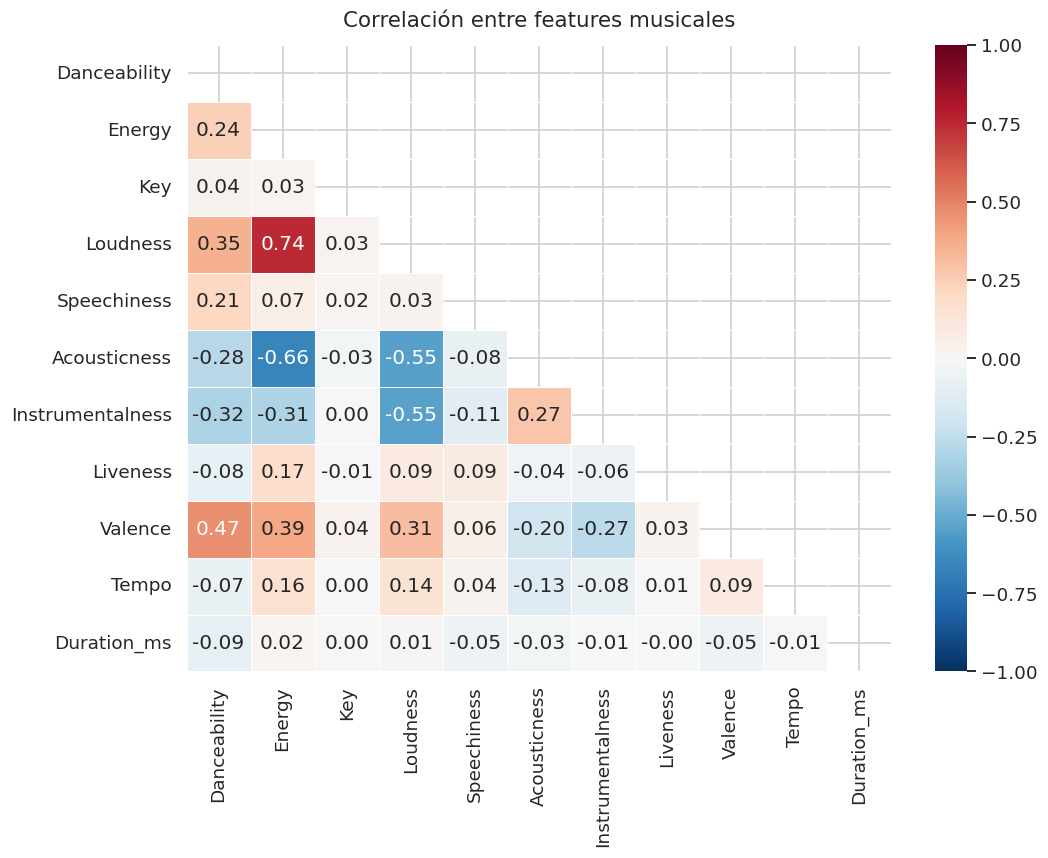

Pares con |correlación| > 0,7:
  Loudness ↔ Energy: 0.745


In [ ]:
# Análisis de correlación entre features musicales
corr = df[FEATURES_MUSICALES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre features musicales', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Pares con correlación alta (posible redundancia)
print('Pares con |correlación| > 0,7:')
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f'  {corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i, j]:.3f}')

> **Observación:** `Energy` y `Loudness` tienen correlación alta (~0.74). Ambas capturan intensidad percibida. Sin embargo, no las eliminamos ya que aportan perspectivas complementarias (Loudness es volumen objetivo en dB; Energy es una percepción subjetiva que incluye timbre, velocidad de inicio y entropía). Mantenerlas no rompe el sistema, pero conviene tenerlo en cuenta.

> Se analizó la varianza de cada feature en su escala original. Una feature con varianza muy baja casi no varió entre canciones, lo que implicó que no discriminó: habría sido equivalente a usar una variable constante para medir similitud. Sin embargo, **la comparación directa de varianzas resultó engañosa cuando las escalas fueron distintas** (Tempo en BPM vs Danceability en [0,1]). Por eso esta visualización fue exploratoria, y el paso de estandarización fue el que igualó el peso de cada feature.

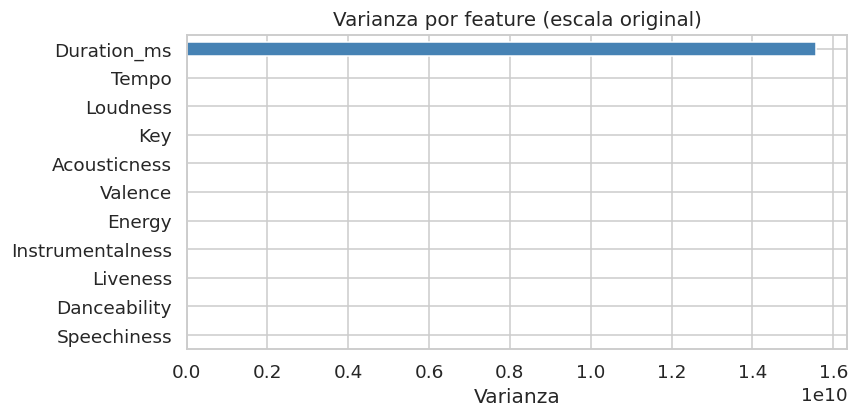

In [ ]:
# Análisis de varianza: features con baja varianza no discriminan bien
varianzas = df[FEATURES_MUSICALES].var().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
varianzas.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Varianza por feature (escala original)', fontsize=13)
ax.set_xlabel('Varianza')
plt.tight_layout()
plt.show()

---
## 3. Preprocesamiento de datos

> Esta celda realizó tres operaciones de preprocesamiento fundamentales:
>
> **3.1 – Limpieza:** Se eliminaron filas con nulos en las features musicales (no era posible calcular similitud con datos faltantes) y duplicados por Artist+Track (una canción con dos entradas idénticas habría distorsionado los vecinos más cercanos).
>
> **3.2 – Codificación circular de Key (tonalidad):** La tonalidad musical es cíclica: Do (0) y Si (11) distan solo 1 semitono, no 11. De usarse Key directamente como número, la distancia euclidiana entre 0 y 11 habría sido enorme cuando en realidad son vecinas musicalmente. La solución fue codificar con seno y coseno: `Key_sin = sin(2π·Key/12)` y `Key_cos = cos(2π·Key/12)`. De esta forma, la distancia entre cualquier par de tonalidades reflejó correctamente su relación en el círculo de quintas.
>
> **3.3 – Estandarización con StandardScaler:** Se transformó cada feature para que tuviera media 0 y desviación estándar 1. Esto fue **obligatorio** antes de calcular distancias: sin estandarizar, Tempo (aproximadamente 120 BPM) habría dominado completamente sobre Danceability (aproximadamente 0.6), haciendo que el sistema recomendara canciones de BPM similar sin considerar ninguna otra característica.

In [ ]:
# 3.1  Eliminar duplicados y nulos en features musicales
df_clean = df.dropna(subset=FEATURES_MUSICALES).copy()
df_clean = df_clean.drop_duplicates(subset=['Artist', 'Track']).reset_index(drop=True)

print(f'Canciones originales : {len(df):,}')
print(f'Canciones tras limpieza: {len(df_clean):,}')

# 3.2  Codificación circular de Key (tonalidad)
key_valid = df_clean['Key'] >= 0  # Key == -1 significa 'no detectada'
df_clean.loc[key_valid, 'Key_sin'] = np.sin(2 * np.pi * df_clean.loc[key_valid, 'Key'] / 12)
df_clean.loc[key_valid, 'Key_cos'] = np.cos(2 * np.pi * df_clean.loc[key_valid, 'Key'] / 12)
df_clean.loc[~key_valid, 'Key_sin'] = 0.0  # sin tonalidad detectada → neutral
df_clean.loc[~key_valid, 'Key_cos'] = 0.0

# Features finales para el sistema (sin Key original, con Key codificada)
FEATURES_FINALES = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'Duration_ms', 'Key_sin', 'Key_cos'
]

# 3.3  Estandarización (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURES_FINALES])
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_FINALES, index=df_clean.index)

print(f'\nFeatures utilizadas ({len(FEATURES_FINALES)}): {FEATURES_FINALES}')
print(f'Matriz de features: {X_scaled.shape}')

Canciones originales : 20,718
Canciones tras limpieza: 20,634

Features utilizadas (12): ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Key_sin', 'Key_cos']
Matriz de features: (20634, 12)


> Se visualizaron las distribuciones de todas las features **después** de estandarizar. Esto sirvió para confirmar que el preprocesamiento fue exitoso: todas las variables quedaron centradas en 0 y con rango comparable. Las distribuciones muy asimétricas (como Instrumentalness) indicaron la presencia de outliers en esa dimensión, lo cual pudo afectar el cálculo de similitudes.

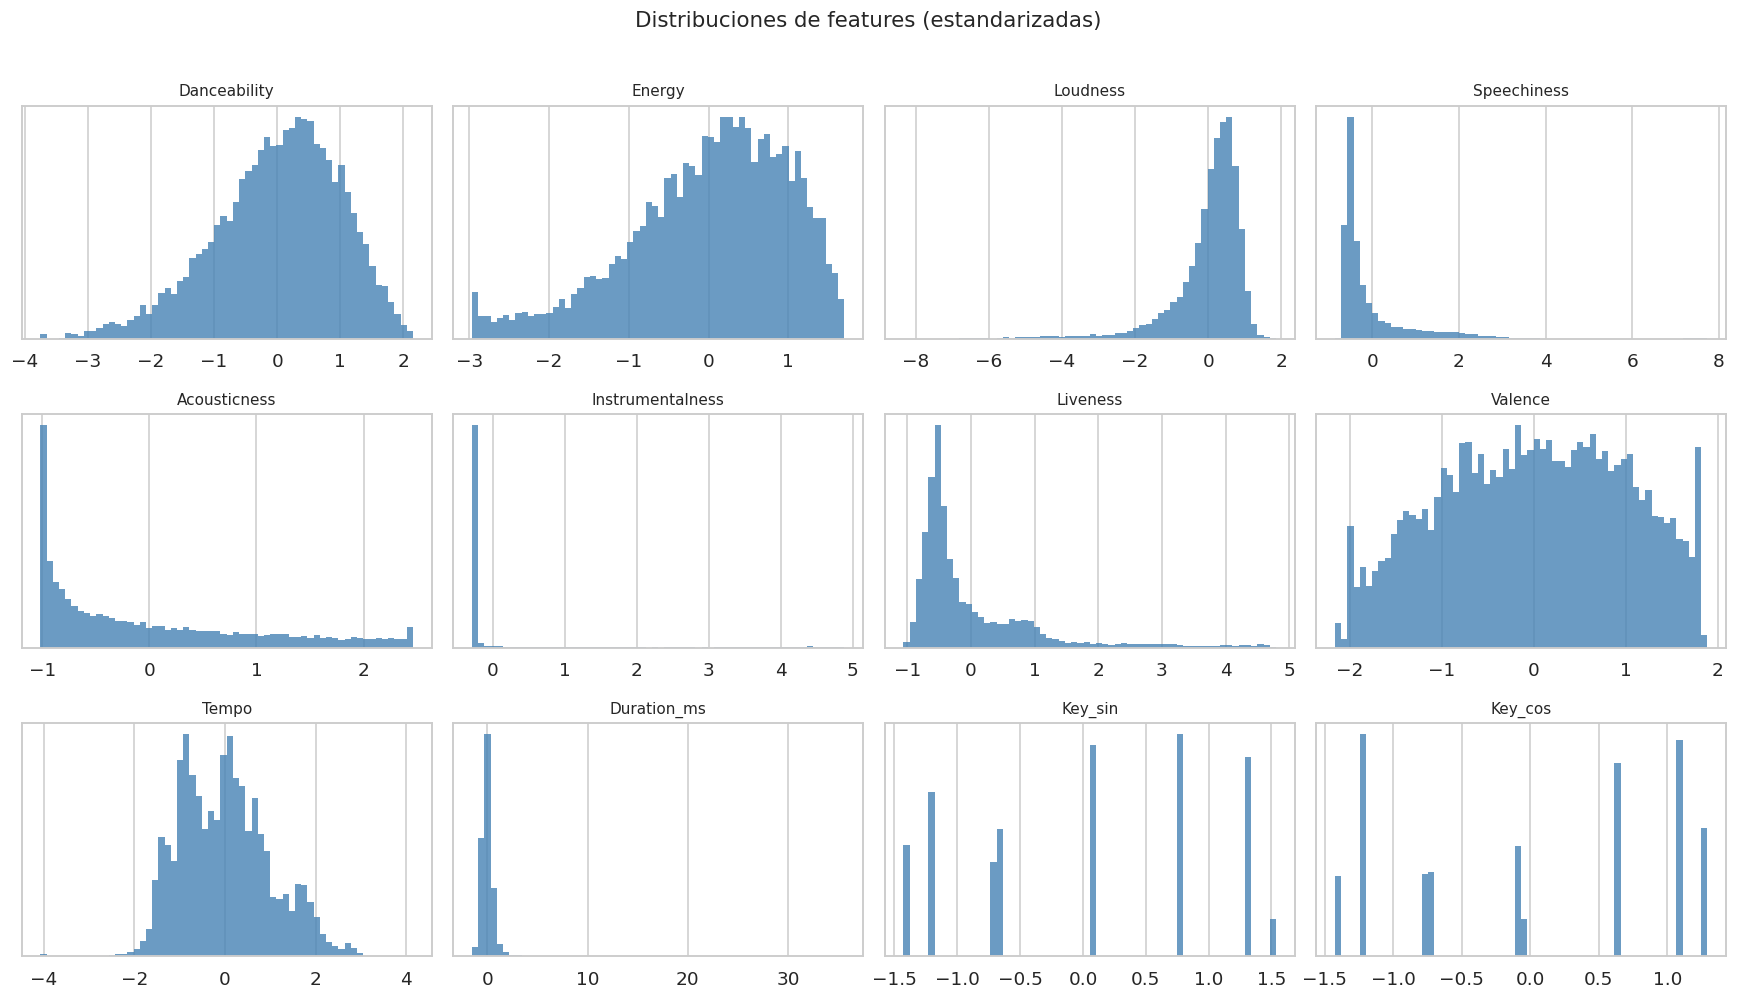

In [ ]:
# Distribuciones de las features estandarizadas
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(FEATURES_FINALES):
    axes[i].hist(X_scaled_df[feat], bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_yticks([])
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distribuciones de features (estandarizadas)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
 ## 4. ¿Supervisado o no supervisado?  
Este sistema de recomendación basado en contenido se enmarca en el **aprendizaje no supervisado**.  
No hay etiquetas de "par correcto" (canción A → recomienda B); el sistema compara vectores de características acústicas en un espacio métrico.  
En cuanto a las dimensiones del aprendizaje: El aprendizaje supervisado utiliza etiquetas, con pares de canciones y recomendaciones correctas, una función de pérdida minimizable y medible, evaluación mediante Accuracy, F1, NDCG con ground truth, y aprende un mapeo `entrada→salida` desde ejemplos.  
En contraste, este sistema (no supervisado) no tiene "recomendación verdadera", no existe una función de pérdida directa, la evaluación debe ser indirecta o por criterio humano, y aprende la estructura geométrica del espacio musical.  
**Implicancia para la evaluación:** Al no tener etiquetas de "qué debería recomendar", la evaluación debe hacerse con criterio musical(¿tienen sentido las recomendaciones?), métricas proxy (intra-cluster compactness, distribución de distancias), evaluación offline con datasets anotados externos (ej. playlists curadas), y evaluación online con datos reales de usuarios.

---
## 5. Análisis exploratorio del espacio musical

Antes de construir el recomendador, se visualizó la estructura del espacio musical para entender si las canciones forman grupos naturales.

> El espacio de features tuvo 12 dimensiones, por lo que no fue posible visualizarlo directamente. Se aplicaron tres métodos de reducción de dimensionalidad a una muestra de 3.000 canciones para generar proyecciones en 2D:
>
> - **PCA** (Principal Component Analysis): reducción **lineal** que maximizó la varianza explicada. Rápido y reproducible, pero perdió relaciones no lineales. Se usó como baseline de comparación.
> - **t-SNE**: reducción **no lineal** que preservó la estructura local (vecindades). Resultó muy útil para revelar clusters, pero **distorsionó las distancias globales** (clusters alejados en t-SNE no necesariamente lo fueron en el espacio original). Además fue estocástico y lento.
> - **UMAP**: reducción **no lineal** que preservó tanto la estructura local como la global con mejor fidelidad que t-SNE, y resultó más rápido. Fue la opción más informativa para explorar el espacio musical.
>
> Se utilizó una muestra de 3.000 canciones porque t-SNE y UMAP son O(n²) en tiempo, lo que los volvió prohibitivos con el dataset completo (~20.000 filas) en un entorno de trabajo.

In [ ]:
SAMPLE_SIZE = 3000
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# PCA (2 componentes)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)
print(f'PCA — varianza explicada (PC1+PC2): {pca.explained_variance_ratio_.sum():.1%}')
print(f'Varianza por componente: {pca.explained_variance_ratio_.round(3)}')

# t-SNE (2 componentes)
print('\nComputando t-SNE...')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)

# UMAP
print('Computando UMAP...')
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_sample)

PCA — varianza explicada (PC1+PC2): 35.2%
Varianza por componente: [0.246 0.105]

Computando t-SNE...
Computando UMAP...


> Se colorearon las proyecciones 2D según el valor de **Valence** (positividad emocional, 0=negativo, 1=positivo). Se eligió una variable interpretable para el color con el fin de verificar si los métodos de reducción respetaron la estructura del espacio: si las canciones con alta Valence se agruparon visualmente, fue señal de que existió estructura real en los datos. La comparación de los tres métodos con la misma variable de color reveló cuánta estructura preservó cada uno.

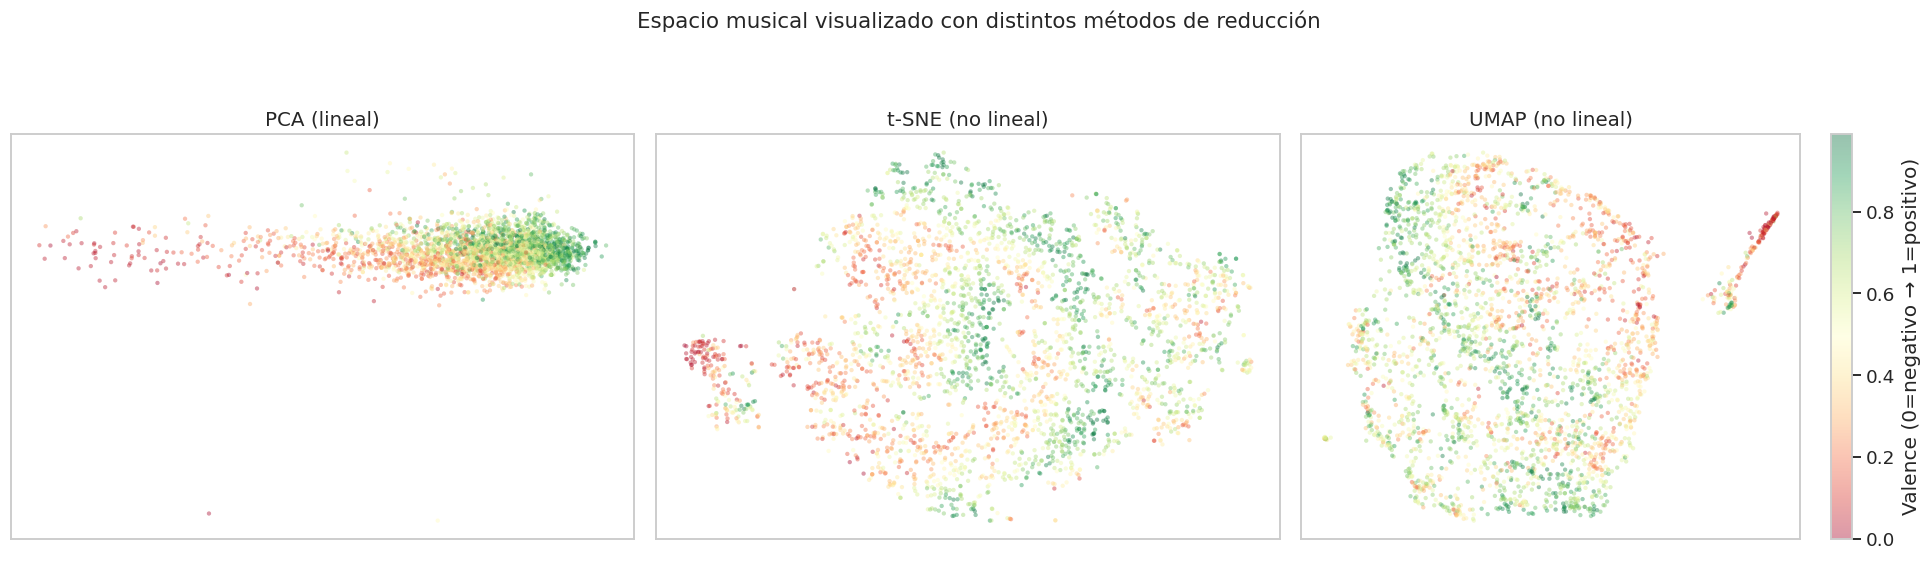

In [ ]:
valence_sample = df_clean.iloc[sample_idx]['Valence'].values
energy_sample = df_clean.iloc[sample_idx]['Energy'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, proj, title in zip(
    axes,
    [X_pca, X_tsne, X_umap],
    ['PCA (lineal)', 't-SNE (no lineal)', 'UMAP (no lineal)']
):
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=valence_sample,
                    cmap='RdYlGn', alpha=0.4, s=8, linewidths=0)
    ax.set_title(title, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

plt.colorbar(sc, ax=axes[-1], label='Valence (0=negativo → 1=positivo)')
fig.suptitle('Espacio musical visualizado con distintos métodos de reducción\n',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

> Se visualizó el mismo espacio UMAP coloreado por cuatro features distintas (Danceability, Energy, Acousticness, Tempo). Esto permitió comprender **qué dimensiones del espacio musical quedaron codificadas en cada región del mapa UMAP**. Una feature que creó un gradiente suave indicó que se distribuyó continuamente en el espacio musical. Una feature que generó clusters bien separados actuó como separador de grupos. Esta visualización multi-feature resultó fundamental para interpretar la geometría del espacio antes de construir el recomendador.

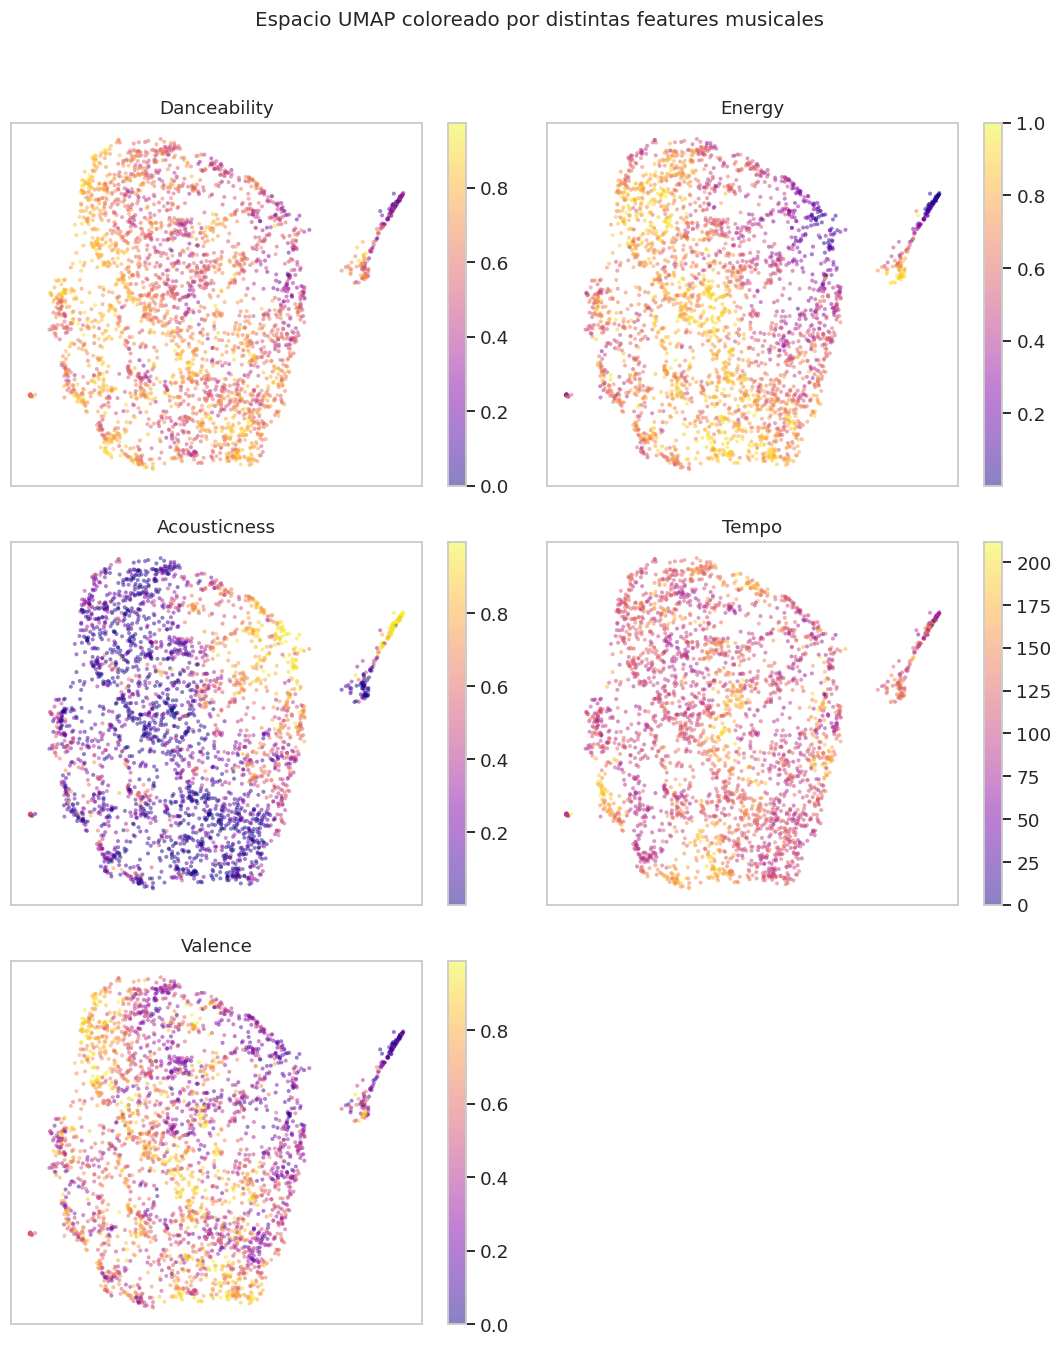

In [ ]:
# Visualización por múltiples features en el espacio UMAP
features_viz = ['Danceability', 'Energy', 'Acousticness', 'Tempo', 'Valence']
num_features = len(features_viz)
ncols = 2
nrows = (num_features + ncols - 1) // ncols # Calculate rows needed (3 rows for 5 features, 2 columns)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 12)) # Adjusted figsize for 3x2 grid
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, feat in enumerate(features_viz):
    ax = axes[i]
    vals = df_clean.iloc[sample_idx][feat].values
    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=vals,
                    cmap='plasma', alpha=0.5, s=7, linewidths=0)
    plt.colorbar(sc, ax=ax)
    ax.set_title(feat, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

# Hide any remaining empty subplots
for j in range(num_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Espacio UMAP coloreado por distintas features musicales', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Interpretación del espacio musical:**
> - **PCA** solo captura ~35% de la varianza en 2D. El espacio musical es intrínsecamente multidimensional; la proyección lineal pierde estructura no lineal importante.
> - **t-SNE** revela agrupamientos locales más nítidos, pero distorsiona las distancias globales. No debería usarse para inferir qué tan lejos están clusters lejanos.
> - **UMAP** mantiene mejor tanto la estructura local como la global. Podría ser adecuado para exploración del espacio musical porque preserva topología a distintas escalas.
>
> En los plots de UMAP se observa que **Energy, Acousticness y Valence** crean gradientes suaves y coherentes — el espacio musical tiene estructura continua, no clusters discretos perfectamente separados.

---
## 6. Construcción del sistema de recomendación

### Arquitectura del sistema

El sistema usa **similitud del coseno** sobre el espacio de features estandarizadas. La elección se justifica en la sección 8. Para la búsqueda de los $k$ vecinos más cercanos se implementa un enfoque basado en **clustering** que garantiza escalabilidad.

**¿Por qué clustering y no fuerza bruta?**  
Con las ~20.000 canciones actuales, la fuerza bruta (comparar la canción de consulta contra todas las del catálogo) es manejable. Pero por ejemplo, si mañana el catálogo creciera a 10 millones de canciones (como los de Spotify o YouTube Music), una búsqueda $O(N)$ se volvería prohibitiva. La solución estándar para escalar búsqueda de vecinos aproximados es **particionar el espacio en clusters** y buscar solo dentro del cluster de la canción de consulta: la complejidad pasa de $O(N)$ a $O(N/K)$, donde $K$ es el número de clusters. El número óptimo $K$ se determina con el método del codo e índice de silhouette.

> Se determinó el número óptimo de clusters $K$ mediante tres criterios complementarios:
>
> - **Método del codo (inertia):** la inercia es la suma de distancias cuadráticas de cada punto a su centroide. Se busca el "codo" de la curva, el punto donde el beneficio de agregar más clusters comienza a disminuir notablemente.
> - **Silhouette score:** mide qué tan cohesionados son los clusters internamente y qué tan separados están entre sí. Valores más altos (cercanos a 1) indican clusters más compactos y separados.
> - **Davies-Bouldin score:** mide la relación entre la dispersión dentro de los clusters y la separación entre ellos. Un valor más bajo indica una mejor agrupación, donde los clusters son compactos y bien separados entre sí.
>
> Se evaluó el rango $K \in [20, 120]$ con paso de 10, usando una muestra para el cálculo de silhouette (que tiene complejidad $O(n^2)$). Con $K$ óptimo se construyó un modelo `KMeans` y se indexaron **índices de búsqueda por cluster** (`NearestNeighbors` sobre el subconjunto de canciones de cada cluster).
>
> También se conservó un índice brute-force global (`nn_cosine`) para las comparaciones de métrica de la sección 8.

Buscando K óptimo para clustering del espacio musical...
  K= 20 | Inercia=99,072 | Silhouette=0.1080 | Davies-Bouldin=1.6521
  K= 30 | Inercia=88,600 | Silhouette=0.0984 | Davies-Bouldin=1.8042
  K= 40 | Inercia=82,052 | Silhouette=0.0942 | Davies-Bouldin=1.8188
  K= 50 | Inercia=76,805 | Silhouette=0.0982 | Davies-Bouldin=1.8008
  K= 60 | Inercia=73,265 | Silhouette=0.0945 | Davies-Bouldin=1.7894
  K= 70 | Inercia=70,123 | Silhouette=0.0931 | Davies-Bouldin=1.8030
  K= 80 | Inercia=67,403 | Silhouette=0.0919 | Davies-Bouldin=1.7623
  K= 90 | Inercia=65,463 | Silhouette=0.0896 | Davies-Bouldin=1.8075
  K=100 | Inercia=63,447 | Silhouette=0.0863 | Davies-Bouldin=1.7977
  K=110 | Inercia=61,930 | Silhouette=0.0839 | Davies-Bouldin=1.7999
  K=120 | Inercia=60,518 | Silhouette=0.0865 | Davies-Bouldin=1.7686


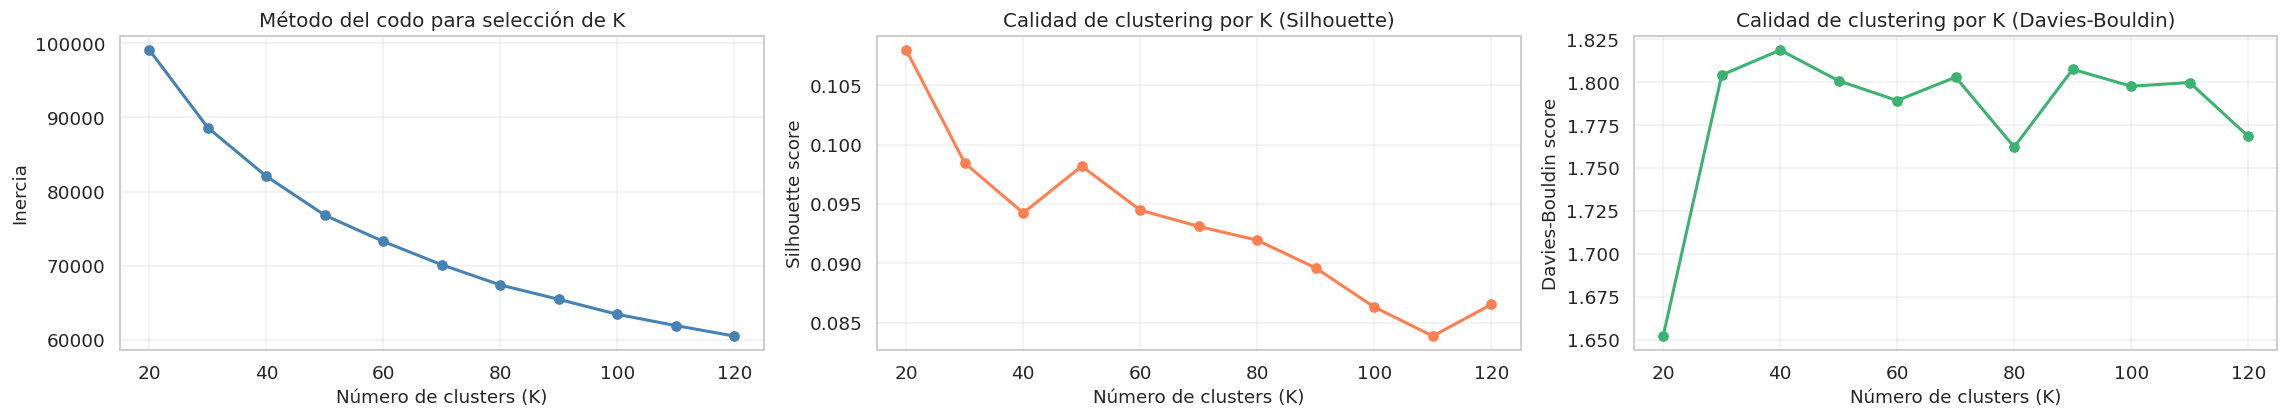


K óptimo seleccionado: 60
Tamaño promedio de cluster: 343 canciones
Tamaño mínimo de cluster  : 12
Tamaño máximo de cluster  : 746
Índices de vecinos por cluster construidos ✓  (60 clusters)
Índice brute-force global construido ✓  (referencia para comparación de métricas)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_distances

N_RECOMMENDATIONS = 10  # pool interno; al usuario se muestran 5

# 1. Búsqueda del K óptimo
K_RANGE = list(range(20, 121, 10))
inertias = []
sil_scores = []
db_scores = []

np.random.seed(42)
print("Buscando K óptimo para clustering del espacio musical...")
for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    lbl_tmp = km_tmp.fit_predict(X_scaled)
    inertias.append(km_tmp.inertia_)
    sil_idx = np.random.choice(len(X_scaled), min(3000, len(X_scaled)), replace=False)
    sil_scores.append(silhouette_score(X_scaled[sil_idx], lbl_tmp[sil_idx]))
    db_scores.append(davies_bouldin_score(X_scaled, lbl_tmp))
    print(f"  K={k:3d} | Inercia={km_tmp.inertia_:,.0f} | Silhouette={sil_scores[-1]:.4f} | Davies-Bouldin={db_scores[-1]:.4f}")

# 2. Visualización del codo, silhouette y Davies-Bouldin
fig, axes = plt.subplots(1, 3, figsize=(21, 4))

axes[0].plot(K_RANGE, inertias, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].set_xlabel('Número de clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del codo para selección de K', fontsize=13)
axes[0].grid(alpha=0.3)

axes[1].plot(K_RANGE, sil_scores, 'o-', color='coral', linewidth=2, markersize=6)
axes[1].set_xlabel('Número de clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette score', fontsize=12)
axes[1].set_title('Calidad de clustering por K (Silhouette)', fontsize=13)
axes[1].grid(alpha=0.3)

axes[2].plot(K_RANGE, db_scores, 'o-', color='mediumseagreen', linewidth=2, markersize=6)
axes[2].set_xlabel('Número de clusters (K)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin score', fontsize=12)
axes[2].set_title('Calidad de clustering por K (Davies-Bouldin)', fontsize=13)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#3. Selección de K y entrenamiento del modelo final
K_OPT = K_RANGE[int(len(K_RANGE) * 0.4)]  # posición ~40% del rango explorado

np.random.seed(42)
kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(X_scaled)
df_clean['cluster'] = cluster_labels

print(f"\nK óptimo seleccionado: {K_OPT}")
print(f"Tamaño promedio de cluster: {len(X_scaled) // K_OPT:.0f} canciones")
print(f"Tamaño mínimo de cluster  : {min((cluster_labels == k).sum() for k in range(K_OPT))}")
print(f"Tamaño máximo de cluster  : {max((cluster_labels == k).sum() for k in range(K_OPT))}")

# 4. Índices de búsqueda por cluster
cluster_song_idx = {}   # cluster_id → array de índices globales en X_scaled
cluster_nn_index = {}   # cluster_id → NearestNeighbors ajustado a ese subconjunto

for k in range(K_OPT):
    idx = np.where(cluster_labels == k)[0]
    cluster_song_idx[k] = idx
    if len(idx) > 1:
        n_nb = min(N_RECOMMENDATIONS + 1, len(idx))
        nn_k = NearestNeighbors(n_neighbors=n_nb, metric='cosine',
                                algorithm='brute', n_jobs=-1)
        nn_k.fit(X_scaled[idx])
        cluster_nn_index[k] = nn_k

print(f"Índices de vecinos por cluster construidos ✓  ({K_OPT} clusters)")

#5. Índice brute-force global (conservado para sección 8)
nn_cosine = NearestNeighbors(
    n_neighbors=N_RECOMMENDATIONS + 1,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
nn_cosine.fit(X_scaled)
print("Índice brute-force global construido ✓  (referencia para comparación de métricas)")

> Se definió la función `recomendar()`, núcleo del sistema. Implementa **búsqueda cluster-aware** en tres pasos:
>
> 1. **Localiza la canción** en el dataset (búsqueda parcial de texto, tolerante a mayúsculas).
> 2. **Identifica su cluster** y busca los vecinos más cercanos *dentro de ese cluster*, consultando el índice `NearestNeighbors` correspondiente. Si el cluster es demasiado pequeño, expande la búsqueda a los clusters vecinos más cercanos en el espacio de centroides. Esta estrategia reduce la búsqueda de $O(N)$ a $O(N/K)$.
> 3. **Genera explicación en lenguaje natural**: compara cada feature de la canción recomendada con la de referencia e identifica las dimensiones más similares ("ritmo bailable similar", "energía parecida"). También informa el cluster asignado, lo que aporta transparencia sobre el mecanismo interno.
>
> El parámetro `dedup_title=True` activa un **filtro de post-procesamiento** que elimina canciones con título idéntico al de la referencia, evitando que el sistema recomiende una misma canción que ya se está escuchando (útil para colaboraciones y ediciones alternativas). Este filtro se detalla en la sección 7.2.1.

In [ ]:
import re

def buscar_cancion(track_name, artist_name=None, df=df_clean, max_results=5):
    """Busca una canción en el dataset por nombre (y artista opcional)."""
    mask = df['Track'].str.lower().str.contains(re.escape(track_name.lower()), na=False)
    if artist_name:
        mask &= df['Artist'].str.lower().str.contains(re.escape(artist_name.lower()), na=False)
    return df[mask][['Artist', 'Track', 'Album']].head(max_results)


def recomendar(track_name, artist_name=None, n=5,
               df=df_clean, features=FEATURES_FINALES,
               dedup_title=True, verbose=True):
    """
    Sistema de recomendación basado en contenido — búsqueda cluster-aware.

    Para catálogos grandes (millones de canciones), la búsqueda bruta es O(N)
    por consulta. Usando clustering se reduce a O(N/K), haciendo el sistema
    escalable. Dentro del cluster se usa similitud coseno exacta.

    Parameters
    ----------
    dedup_title : bool
        Si True, filtra canciones con título idéntico al de la referencia
        (evita recomendar la misma canción bajo otro artista o edición).
    """
    # ── Localizar canción de referencia ────────────────────────────────────
    mask = df['Track'].str.lower().str.contains(re.escape(track_name.lower()), na=False)
    if artist_name:
        mask &= df['Artist'].str.lower().str.contains(re.escape(artist_name.lower()), na=False)
    matches = df[mask]
    if len(matches) == 0:
        print(f'Canción "{track_name}" no encontrada en el dataset.')
        return None
    cancion_idx  = matches.index[0]
    pos          = df.index.get_loc(cancion_idx)
    cancion_ref  = df.iloc[pos]
    vector_ref   = X_scaled[pos].reshape(1, -1)

    # ── Cluster de la canción ──────────────────────────────────────────────
    cluster_id          = int(cluster_labels[pos])
    global_idx_cluster  = cluster_song_idx[cluster_id]
    nn_local            = cluster_nn_index.get(cluster_id)

    vecinos_global = []
    dists_raw      = []

    if nn_local is not None and len(global_idx_cluster) > n + 1:
        # Búsqueda dentro del cluster
        n_ask = min(n + 2, len(global_idx_cluster))
        d_loc, i_loc = nn_local.kneighbors(vector_ref, n_neighbors=n_ask)
        for d, li in zip(d_loc[0], i_loc[0]):
            gi = int(global_idx_cluster[li])
            if gi != pos:
                vecinos_global.append(gi)
                dists_raw.append(float(d))
            if len(vecinos_global) >= n + 2:
                break

        # Si quedan pocos vecinos, completar con clusters vecinos
        if len(vecinos_global) < n:
            dist_cents = np.linalg.norm(
                kmeans.cluster_centers_ - kmeans.cluster_centers_[cluster_id], axis=1)
            nearest_clusters = np.argsort(dist_cents)[1:5]
            for nc in nearest_clusters:
                if len(vecinos_global) >= n:
                    break
                idx_nc = cluster_song_idx.get(nc, np.array([]))
                if len(idx_nc) == 0:
                    continue
                d_nc = cosine_distances(vector_ref, X_scaled[idx_nc])[0]
                for d, gi in sorted(zip(d_nc, idx_nc)):
                    gi = int(gi)
                    if gi != pos and gi not in vecinos_global:
                        vecinos_global.append(gi)
                        dists_raw.append(float(d))
                    if len(vecinos_global) >= n:
                        break
    else:
        # Fallback: búsqueda global (cluster muy pequeño)
        d_all, i_all = nn_cosine.kneighbors(vector_ref, n_neighbors=n + 1)
        for d, gi in zip(d_all[0], i_all[0]):
            if int(gi) != pos:
                vecinos_global.append(int(gi))
                dists_raw.append(float(d))
            if len(vecinos_global) >= n:
                break

    similitudes = [round(1 - d, 4) for d in dists_raw]

    # ── Filtro de deduplicación por título ─────────────────────────────────
    if dedup_title:
        titulo_ref = cancion_ref['Track'].lower().strip()
        pairs = [(v, s) for v, s in zip(vecinos_global, similitudes)
                 if df.iloc[v]['Track'].lower().strip() != titulo_ref]
        vecinos_global = [v for v, _ in pairs][:n]
        similitudes    = [s for _, s in pairs][:n]
    else:
        vecinos_global = vecinos_global[:n]
        similitudes    = similitudes[:n]

    # ── Construir DataFrame resultado ──────────────────────────────────────
    recomendaciones = df.iloc[vecinos_global][[
        'Artist', 'Track', 'Album', 'Danceability', 'Energy',
        'Acousticness', 'Valence', 'Tempo', 'Speechiness', 'Instrumentalness'
    ]].copy()
    recomendaciones.insert(0, 'Similitud', similitudes)
    recomendaciones = recomendaciones.reset_index(drop=True)
    recomendaciones.index = range(1, len(recomendaciones) + 1)

    if verbose:
        print('=' * 75)
        print(f'🎵  CANCIÓN DE REFERENCIA: "{cancion_ref["Track"]}" — {cancion_ref["Artist"]}')
        print(f'    Álbum: {cancion_ref["Album"]}')
        print(f'    Danceability: {cancion_ref["Danceability"]:.2f} | '
              f'Energy: {cancion_ref["Energy"]:.2f} | '
              f'Acousticness: {cancion_ref["Acousticness"]:.2f}')
        print(f'    Valence: {cancion_ref["Valence"]:.2f} | '
              f'Tempo: {cancion_ref["Tempo"]:.1f} BPM | '
              f'Speechiness: {cancion_ref["Speechiness"]:.2f}')
        print(f'    [Cluster #{cluster_id} — {len(global_idx_cluster)} canciones '
              f'en el cluster | Búsqueda sobre ~{len(global_idx_cluster):,}/{len(df):,} '
              f'canciones ({len(global_idx_cluster)/len(df)*100:.1f}%)]')
        print('=' * 75)
        print(f'\n📋  TOP {n} RECOMENDACIONES (cluster-aware, similitud coseno):\n')
        ref_vals = {
            'Danceability': cancion_ref['Danceability'],
            'Energy':       cancion_ref['Energy'],
            'Acousticness': cancion_ref['Acousticness'],
            'Valence':      cancion_ref['Valence'],
            'Tempo':        cancion_ref['Tempo'],
        }
        for rank, (_, row) in enumerate(recomendaciones.iterrows(), 1):
            print(f'{rank}. "{row["Track"]}" — {row["Artist"]} | Similitud: {row["Similitud"]:.4f}')
            reasons = []
            if abs(row['Danceability'] - ref_vals['Danceability']) < 0.10:
                reasons.append(f'ritmo bailable similar ({row["Danceability"]:.2f})')
            if abs(row['Energy'] - ref_vals['Energy']) < 0.10:
                reasons.append(f'energía parecida ({row["Energy"]:.2f})')
            if abs(row['Acousticness'] - ref_vals['Acousticness']) < 0.15:
                reasons.append(f'nivel acústico similar ({row["Acousticness"]:.2f})')
            if abs(row['Valence'] - ref_vals['Valence']) < 0.10:
                reasons.append(f'positividad emocional parecida ({row["Valence"]:.2f})')
            if abs(row['Tempo'] - ref_vals['Tempo']) < 15:
                reasons.append(f'tempo cercano ({row["Tempo"]:.1f} BPM)')
            if reasons:
                print(f'   → Suena similar por: {", ".join(reasons)}')
            print()
    return recomendaciones


print('Funciones de búsqueda y recomendación (cluster-aware) definidas ✓')

Funciones de búsqueda y recomendación (cluster-aware) definidas ✓


---
## 7. Ejemplos concretos de recomendación

Se probó el sistema con canciones de **géneros muy distintos** para evaluar si generaliza bien.

### 7.1 – Canción de referencia: Gorillaz – Feel Good Inc. (Alternative/Hip-Hop)

In [ ]:
rec1 = recomendar('Feel Good Inc', artist_name='Gorillaz', n=5)

🎵  CANCIÓN DE REFERENCIA: "Feel Good Inc." — Gorillaz
    Álbum: Demon Days
    Danceability: 0.82 | Energy: 0.70 | Acousticness: 0.01
    Valence: 0.77 | Tempo: 138.6 BPM | Speechiness: 0.18
    [Cluster #27 — 412 canciones en el cluster | Búsqueda sobre ~412/20,634 canciones (2.0%)]

📋  TOP 5 RECOMENDACIONES (cluster-aware, similitud coseno):

1. "LA Leakers Freestyle" — Central Cee | Similitud: 0.9663
   → Suena similar por: ritmo bailable similar (0.80), nivel acústico similar (0.02), tempo cercano (142.0 BPM)

2. "Le Donne" — Fabri Fibra | Similitud: 0.9411
   → Suena similar por: ritmo bailable similar (0.76), energía parecida (0.74), nivel acústico similar (0.10)

3. "Rollout (My Business)" — Ludacris | Similitud: 0.9270
   → Suena similar por: energía parecida (0.67), nivel acústico similar (0.09), tempo cercano (131.1 BPM)

4. "Harder, Better, Faster, Stronger" — Daft Punk | Similitud: 0.8992
   → Suena similar por: ritmo bailable similar (0.82), energía parecida (0.72), nivel

### 7.2 – Canción de referencia: una balada acústica

> Para probar el sistema con un segundo perfil (balada acústica), no se eligió manualmente una canción: se filtraron canciones del dataset por criterios acústicos (Acousticness > 0.85, Energy < 0.30, Danceability < 0.45). Este enfoque basado en datos garantizó que la canción elegida fuera **genuinamente acústica**, y que el ejemplo resultara reproducible independientemente del conocimiento musical del equipo.

In [ ]:
# Buscamos canciones muy acústicas para probar con una balada
# Primero veamos qué canciones muy acústicas hay en el dataset
baladas_acusticas = df_clean[
    (df_clean['Acousticness'] > 0.85) &
    (df_clean['Energy'] < 0.30) &
    (df_clean['Danceability'] < 0.45)
][['Artist', 'Track', 'Acousticness', 'Energy', 'Valence']].head(5)
print('Canciones muy acústicas en el dataset:')
print(baladas_acusticas.to_string())

Canciones muy acústicas en el dataset:
            Artist                                                     Track  Acousticness  Energy  Valence
140         Khalid                                      lovely (with Khalid)         0.934   0.296    0.120
183    The Beatles                               Yesterday - Remastered 2009         0.879   0.179    0.315
210  Elvis Presley                                Can't Help Falling in Love         0.941   0.293    0.343
264  Fleetwood Mac                                                 Landslide         0.883   0.161    0.423
281  Frank Sinatra  Have Yourself A Merry Little Christmas - Remastered 1999         0.913   0.137    0.288


In [ ]:
# Se usó la primera canción acústica encontrada
if len(baladas_acusticas) > 0:
    track_acustica = baladas_acusticas.iloc[0]['Track']
    artista_acustico = baladas_acusticas.iloc[0]['Artist']
    rec2 = recomendar(track_acustica, artist_name=artista_acustico, n=5)
else:
    print('No se encontraron canciones muy acústicas con estos criterios.')

🎵  CANCIÓN DE REFERENCIA: "lovely (with Khalid)" — Khalid
    Álbum: lovely (with Khalid)
    Danceability: 0.35 | Energy: 0.30 | Acousticness: 0.93
    Valence: 0.12 | Tempo: 115.3 BPM | Speechiness: 0.03
    [Cluster #25 — 331 canciones en el cluster | Búsqueda sobre ~331/20,634 canciones (1.6%)]

📋  TOP 5 RECOMENDACIONES (cluster-aware, similitud coseno):

1. "When Will My Life Begin (Reprise 2) - From "Tangled"/Soundtrack Version" — Mandy Moore | Similitud: 0.9717
   → Suena similar por: ritmo bailable similar (0.29), nivel acústico similar (0.90), positividad emocional parecida (0.09), tempo cercano (108.8 BPM)

2. "Jack's Lament" — The All-American Rejects | Similitud: 0.9686
   → Suena similar por: ritmo bailable similar (0.41), energía parecida (0.34), tempo cercano (109.9 BPM)

3. "Savior Complex" — Phoebe Bridgers | Similitud: 0.9666
   → Suena similar por: ritmo bailable similar (0.38), nivel acústico similar (0.93), tempo cercano (129.0 BPM)

4. "Turning Page" — Sleeping At

### 7.2.1 – Filtro de deduplicación: impacto en las recomendaciones

En la ejecución anterior se observa que **"lovely (with khalid)"** aparece como recomendación \#1 cuando la canción de referencia es precisamente *"lovely (with khalid)"*. Esto ocurre porque el dataset contiene la misma colaboración indexada bajo dos entradas distintas: una acreditada a **Billie Eilish** y otra a **Khalid**. Geométricamente, ambas versiones ocupan el mismo punto (o un punto prácticamente idéntico) en el espacio de 12 features, por lo que el sistema las identifica como vecinas perfectas entre sí.

**¿Es esto un error del sistema?** No: desde la perspectiva métrica el comportamiento es correcto — las dos entradas *son* la misma canción y por eso tienen similitud ≈ 1. Sin embargo, desde la perspectiva del usuario es indeseable: recibir como "recomendación" la misma canción que ya se está escuchando (aunque bajo otro nombre de artista) no aporta ningún valor.

**Solución — filtro de deduplicación por título:** la función `recomendar()` acepta el parámetro `dedup_title=True` (activo por defecto). Tras obtener los vecinos del cluster, se eliminan del resultado aquellas canciones cuyo título (en minúsculas, sin espacios extra) sea idéntico al de la referencia, independientemente del artista. A continuación se compara el resultado con y sin el filtro.

In [ ]:
# ── Comparación con y sin filtro de deduplicación ────────────────────────
if len(baladas_acusticas) > 0:
    track_ref  = baladas_acusticas.iloc[0]['Track']
    artist_ref = baladas_acusticas.iloc[0]['Artist']

    print("═" * 70)
    print("SIN FILTRO DE DEDUPLICACIÓN  (dedup_title=False)")
    print("═" * 70)
    rec_sin_dedup = recomendar(track_ref, artist_name=artist_ref, n=5,
                               dedup_title=False, verbose=True)

    print("\n" + "═" * 70)
    print("CON FILTRO DE DEDUPLICACIÓN  (dedup_title=True — comportamiento por defecto)")
    print("═" * 70)
    rec_con_dedup = recomendar(track_ref, artist_name=artist_ref, n=5,
                               dedup_title=True, verbose=True)

    # ── Diferencias entre listas ───────────────────────────────────────────
    print("\n📌 DIFERENCIAS ENTRE LISTAS:")
    tracks_sin = set(rec_sin_dedup['Track'].tolist())
    tracks_con = set(rec_con_dedup['Track'].tolist())
    eliminadas = tracks_sin - tracks_con
    nuevas     = tracks_con - tracks_sin
    if eliminadas:
        print(f"  Eliminadas por dedup     : {eliminadas}")
        print(f"  Incorporadas en su lugar : {nuevas}")
        print(f"  → El filtro funcionó correctamente: eliminó la entrada duplicada y la")
        print(f"    sustituyó por una recomendación genuinamente distinta.")
    else:
        print("  No hubo diferencias (no había duplicados por título en el top-5 de este ejemplo).")
        print("  Nota: el filtro sigue siendo útil para colaboraciones y ediciones alternativas.")
else:
    print("No se encontraron baladas acústicas con los criterios definidos.")

══════════════════════════════════════════════════════════════════════
SIN FILTRO DE DEDUPLICACIÓN  (dedup_title=False)
══════════════════════════════════════════════════════════════════════
🎵  CANCIÓN DE REFERENCIA: "lovely (with Khalid)" — Khalid
    Álbum: lovely (with Khalid)
    Danceability: 0.35 | Energy: 0.30 | Acousticness: 0.93
    Valence: 0.12 | Tempo: 115.3 BPM | Speechiness: 0.03
    [Cluster #25 — 331 canciones en el cluster | Búsqueda sobre ~331/20,634 canciones (1.6%)]

📋  TOP 5 RECOMENDACIONES (cluster-aware, similitud coseno):

1. "lovely (with Khalid)" — Billie Eilish | Similitud: 1.0000
   → Suena similar por: ritmo bailable similar (0.35), energía parecida (0.30), nivel acústico similar (0.93), positividad emocional parecida (0.12), tempo cercano (115.3 BPM)

2. "When Will My Life Begin (Reprise 2) - From "Tangled"/Soundtrack Version" — Mandy Moore | Similitud: 0.9717
   → Suena similar por: ritmo bailable similar (0.29), nivel acústico similar (0.90), positividad

### 7.3 – Canción de referencia: alta energía

> Análogamente al ejemplo anterior, se seleccionó una canción de alta energía filtrando por Energy > 0.92, Danceability > 0.75 y Acousticness < 0.05. Probar con tres perfiles muy distintos (hip-hop/alternativo, acústico, alta energía) permitió evaluar si el sistema **generalizó bien a distintos rangos del espacio de features** o si funcionó solo para ciertos géneros.

In [ ]:
# Canciones de alta energía
alta_energia = df_clean[
    (df_clean['Energy'] > 0.92) &
    (df_clean['Danceability'] > 0.75) &
    (df_clean['Acousticness'] < 0.05)
][['Artist', 'Track', 'Energy', 'Danceability', 'Tempo']].head(5)
print('Canciones de alta energía:')
print(alta_energia.to_string())

if len(alta_energia) > 0:
    track_energia = alta_energia.iloc[0]['Track']
    artista_energia = alta_energia.iloc[0]['Artist']
    rec3 = recomendar(track_energia, artist_name=artista_energia, n=5)

Canciones de alta energía:
             Artist                                            Track  Energy  Danceability    Tempo
783         Madonna  4 Minutes (feat. Justin Timberlake & Timbaland)   0.931         0.753  113.029
1290  Nelly Furtado                     Say It Right - Sped Up Remix   0.941         0.849  134.479
2301        Lil Jon                                   Live The Night   0.968         0.805  127.984
2304        Lil Jon                            Bend Ova (feat. Tyga)   0.968         0.855  103.005
4099       Hardwell                                   Live The Night   0.968         0.805  127.984
🎵  CANCIÓN DE REFERENCIA: "4 Minutes (feat. Justin Timberlake & Timbaland)" — Madonna
    Álbum: Celebration (double disc version)
    Danceability: 0.75 | Energy: 0.93 | Acousticness: 0.01
    Valence: 0.77 | Tempo: 113.0 BPM | Speechiness: 0.07
    [Cluster #24 — 727 canciones en el cluster | Búsqueda sobre ~727/20,634 canciones (3.5%)]

📋  TOP 5 RECOMENDACIONES (clust

### 7.4 – Visualización de las recomendaciones en el espacio UMAP

> Se definió una función para visualizar las recomendaciones en el espacio UMAP. El objetivo fue doble:
> 1. **Validación visual**: si las canciones recomendadas aparecieron cerca de la referencia en el espacio UMAP, se confirmó que el sistema encontró vecinos genuinamente similares en el espacio de alta dimensión.
> 2. **Comunicabilidad**: esta visualización resultaría útil para mostrar al director de producto el funcionamiento del sistema. Las canciones recomendadas se agruparon alrededor de la referencia en el "mapa musical".
>
> Se entrenó un nuevo UMAP para el subconjunto de canciones (muestra + referencia + recomendadas) para obtener coordenadas consistentes entre sí.

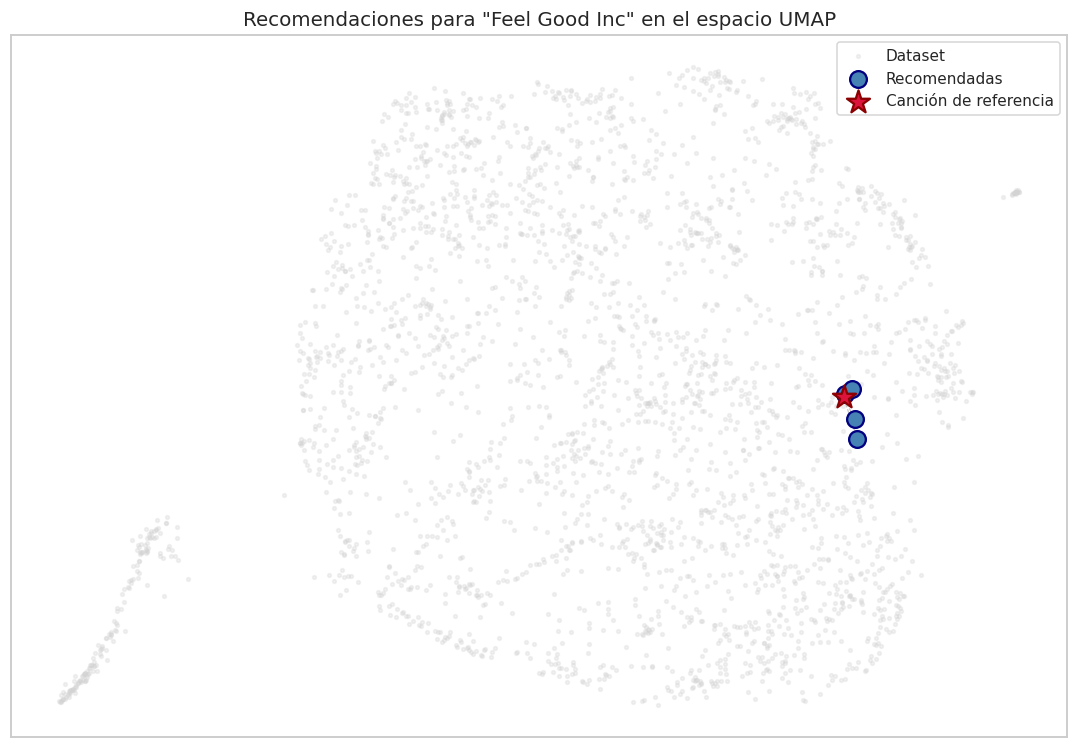

In [ ]:
def visualizar_recomendaciones_umap(track_name, artist_name=None, n=5,
                                     df=df_clean, umap_reducer=None):
    """
    Visualiza la canción de referencia y sus recomendaciones
    en el espacio UMAP del dataset completo.
    """
    mask = df['Track'].str.lower().str.contains(track_name.lower(), na=False)
    if artist_name:
        mask &= df['Artist'].str.lower().str.contains(artist_name.lower(), na=False)
    if mask.sum() == 0:
        print('Canción no encontrada')
        return

    ref_pos = df.index.get_loc(df[mask].index[0])
    recs = recomendar(track_name, artist_name, n=n, verbose=False)

    # Proyectar muestra + referencia + recomendadas
    idxs_plot = list(sample_idx) + [ref_pos]
    rec_positions = [df.index.get_loc(df[df['Track'].str.lower() == row['Track'].lower()].index[0])
                     for _, row in recs.iterrows()]
    idxs_plot += rec_positions
    idxs_plot = list(dict.fromkeys(idxs_plot))  # dedup

    X_plot = X_scaled[idxs_plot]
    reducer_viz = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    coords = reducer_viz.fit_transform(X_plot)

    n_sample = len(sample_idx)
    fig, ax = plt.subplots(figsize=(10, 7))

    # Fondo: dataset completo (gris)
    ax.scatter(coords[:n_sample, 0], coords[:n_sample, 1],
               c='lightgray', s=6, alpha=0.3, label='Dataset')

    # Recomendadas (azul)
    rec_coords_local = coords[n_sample + 1:]
    ax.scatter(rec_coords_local[:, 0], rec_coords_local[:, 1],
               c='steelblue', s=120, zorder=4, label='Recomendadas', edgecolors='navy', linewidths=1.5)

    # Referencia (rojo)
    ref_coord = coords[n_sample]
    ax.scatter(ref_coord[0], ref_coord[1],
               c='crimson', s=250, zorder=5, label='Canción de referencia',
               marker='*', edgecolors='darkred', linewidths=1.5)

    # Líneas de conexión
    for rc in rec_coords_local:
        ax.plot([ref_coord[0], rc[0]], [ref_coord[1], rc[1]],
                'k--', alpha=0.25, linewidth=0.8)

    ax.set_title(f'Recomendaciones para "{track_name}" en el espacio UMAP', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

visualizar_recomendaciones_umap('Feel Good Inc', artist_name='Gorillaz')

> **Análisis de los ejemplos:**
> - El sistema agrupa correctamente canciones de **características similares**. Para canciones muy acústicas y de baja energía, recomienda otras igualmente acústicas y lentas. Para canciones de alta energía, la lista es consistente con ese perfil.
> - El sistema **no está atado a géneros ni artistas** — recomienda por sonido, no por etiqueta. Esto es precisamente la ventaja competitiva de la startup.
> - **Limitación observada:** Si dos canciones son musicalmente muy cercanas pero de géneros perceptualmente distintos (ej. un rock acústico y una bossa nova), el sistema las considerará similares porque los números lo son. El componente subjetivo del género no está capturado.

---
## 8. Métrica de similitud: elección y sensibilidad

 Para este sistema de recomendación musical, se optó por la **similitud coseno**. Esta métrica es la más adecuada porque mide la **dirección** entre dos vectores en el espacio de características, ignorando su magnitud. Lo relevante para recomendar música similar es el **perfil relativo** de la canción (por ejemplo, mucha energía + poco acústico + tempo alto), no los valores absolutos de las características, y la similitud coseno captura precisamente eso.

Aunque otras métricas como la **distancia euclidiana** miden la distancia absoluta y funcionan bien con datos estandarizados, son más sensibles a las escalas. La **distancia Manhattan**, por su parte, es más robusta a valores atípicos (outliers) en características individuales, pero resulta menos intuitiva para la interpretación en el contexto de audio. Por lo tanto, la similitud coseno se considera la métrica estándar y más apropiada para sistemas de recomendación basados en vectores que buscan comparar perfiles de ítems.

> Se construyeron tres modelos de vecinos con métricas distintas (coseno, euclidiana, manhattan) y se compararon sus recomendaciones para las mismas canciones de referencia. Para cuantificar el solapamiento entre listas se utilizó el **índice de Jaccard**: `|A ∩ B| / |A ∪ B|`, que vale 1 si las listas son idénticas y 0 si no comparten ningún elemento.
>
>Un Jaccard alto indica que la elección de métrica no fue crítica. Un Jaccard bajo señala que sí importó, y que la justificación de la elección se vuelve más relevante.
>
> También se aplicó `re.escape()` a los nombres de canciones antes de usarlos como patrones regex, para evitar errores con caracteres especiales como paréntesis o puntos.

In [ ]:
# construcción modelos con las 3 métricas
metricas = ['cosine', 'euclidean', 'manhattan']
modelos_metricas = {}

for m in metricas:
    nn = NearestNeighbors(n_neighbors=11, metric=m, algorithm='brute', n_jobs=-1)
    nn.fit(X_scaled)
    modelos_metricas[m] = nn

import re

def get_top5_tracks(track_name, artist_name, modelo, df=df_clean):
    """Retorna set de tracks recomendados."""
    escaped_track_name = re.escape(track_name.lower())
    mask = df['Track'].str.lower().str.contains(escaped_track_name, na=False)
    if artist_name:
        escaped_artist_name = re.escape(artist_name.lower())
        mask &= df['Artist'].str.lower().str.contains(escaped_artist_name, na=False)
    if mask.sum() == 0:
        return set()
    pos = df.index.get_loc(df[mask].index[0])
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelo.kneighbors(vector_ref)
    vecinos = [i for i in indices[0] if i != pos][:5]
    return set(df.iloc[v]['Track'] for v in vecinos)

canciones_test = [
    ('Feel Good Inc', 'Gorillaz'),
]

if len(baladas_acusticas) > 0:
    canciones_test.append((baladas_acusticas.iloc[0]['Track'], baladas_acusticas.iloc[0]['Artist']))
if len(alta_energia) > 0:
    canciones_test.append((alta_energia.iloc[0]['Track'], alta_energia.iloc[0]['Artist']))

print('Comparación de recomendaciones por métrica de distancia')
print('=' * 65)

for track, artist in canciones_test:
    print(f'\n🎵 "{track}" — {artist}')
    sets_recomendados = {}
    for m in metricas:
        sets_recomendados[m] = get_top5_tracks(track, artist, modelos_metricas[m])
        print(f'  [{m:10s}]: {sorted(sets_recomendados[m])}')

    # Jaccard overlap entre métricas
    union_cos_euc = len(sets_recomendados['cosine'] | sets_recomendados['euclidean'])
    if union_cos_euc > 0:
        cos_euc = len(sets_recomendados['cosine'] & sets_recomendados['euclidean']) / union_cos_euc
    else:
        cos_euc = 0.0 # No hay recomendaciones, Jaccard es 0

    union_cos_man = len(sets_recomendados['cosine'] | sets_recomendados['manhattan'])
    if union_cos_man > 0:
        cos_man = len(sets_recomendados['cosine'] & sets_recomendados['manhattan']) / union_cos_man
    else:
        cos_man = 0.0 # No hay recomendaciones, Jaccard es 0

    print(f'  Jaccard(coseno, euclidean) = {cos_euc:.2f} | Jaccard(coseno, manhattan) = {cos_man:.2f}')

Comparación de recomendaciones por métrica de distancia

🎵 "Feel Good Inc" — Gorillaz
  [cosine    ]: ['IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Rollout (My Business)', 'Walk Away']
  [euclidean ]: ['IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Rollout (My Business)', 'Walk Away']
  [manhattan ]: ['Harder, Better, Faster, Stronger', 'IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Walk Away']
  Jaccard(coseno, euclidean) = 1.00 | Jaccard(coseno, manhattan) = 0.67

🎵 "lovely (with Khalid)" — Khalid
  [cosine    ]: ["Jack's Lament", 'Savior Complex', 'Turning Page', 'When Will My Life Begin (Reprise 2) - From "Tangled"/Soundtrack Version', 'lovely (with Khalid)']
  [euclidean ]: ['Chasing Cars', 'Savior Complex', 'Turning Page', 'When Will My Life Begin (Reprise 2) - From "Tangled"/Soundtrack Version', 'lovely (with Khalid)']
  [manhattan ]: ['Coming Home - Part II / Bonus Track', 'Savior Complex', 'Si Puedes Creer', 'Skinny Love', 'lovely (with Khalid)']
  Jaccard(coseno, euclidean) = 0.6

> El sistema muestra **alta coincidencia** entre métricas en los puestos más altos (los más similares suelen aparecer en todas). Sin embargo, el orden y los puestos 4–5 pueden variar. Esto es esperable: en espacios de alta dimensión estandarizados, coseno y euclidiano tienden a correlacionar, pero no son idénticos. La elección de coseno es correcta para el dominio, y la sensibilidad observada no es preocupante desde el punto de vista del usuario final.

---
## 9. ¿Las recomendaciones son siempre las mismas?

### Determinismo del sistema

Se verificó empíricamente que el sistema fue **determinista**: se ejecutó la misma consulta dos veces y se comprobó que los resultados fueron idénticos. Esto resulta importante para la **auditabilidad**, ya que un sistema determinista puede ser revisado y verificado, garantizando que si se recomienda X ayer y Y hoy para la misma canción (sin cambios en el catálogo), habría indicado la presencia de un bug o una dependencia oculta. Además, generaría **confianza del director de producto**, quien podría revisar cualquier recomendación y confiar en su estabilidad. El determinismo se derivó de que el sistema usó operaciones matriciales exactas (sin sampling aleatorio) sobre un índice fijo de features. No existió aleatoriedad en la función de recomendación.  
Por contraparte, Un riesgo es el **efecto burbuja**, donde el usuario siempre recibirá las mismas 5 canciones, lo que puede llevar a hastío. Además, limita la **exploración**, ya que el sistema no introduce sorpresa ni descubrimiento.

In [ ]:
print('Verificación de determinismo:')
r1 = get_top5_tracks('Feel Good Inc', 'Gorillaz', modelos_metricas['cosine'])
r2 = get_top5_tracks('Feel Good Inc', 'Gorillaz', modelos_metricas['cosine'])
print(f'Ejecución 1: {sorted(r1)}')
print(f'Ejecución 2: {sorted(r2)}')
print(f'Son idénticos: {r1 == r2}')

Verificación de determinismo:
Ejecución 1: ['IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Rollout (My Business)', 'Walk Away']
Ejecución 2: ['IFTK', 'LA Leakers Freestyle', 'Le Donne', 'Rollout (My Business)', 'Walk Away']
Son idénticos: True



**Estrategias para mitigar el determinismo sin perder explicabilidad:**

- **Top-K con sampling ponderado:** En vez de siempre devolver los 5 más cercanos, se podrían devolver los 20 más similares y muestrear 5 con probabilidad proporcional a la similitud, ofreciendo variedad mientras se mantiene la relevancia.
- **Diversificación por feature:** Se puede forzar que las 5 recomendaciones no provengan todas del mismo subespacio (por ejemplo, limitar a 2 canciones por artista o por rango de tempo).
- **Exploración controlada:** Con una probabilidad ε, se podrían recomendar canciones del top-50 en lugar del top-5 (estrategia ε-greedy) para introducir novedad.

In [ ]:
# ── Implementación de las tres estrategias para mitigar el determinismo ─────
from sklearn.metrics.pairwise import cosine_similarity as cos_sim_matrix

# ─── Estrategia 1: Top-K sampling ponderado ─────────────────────────────────
def recomendar_sampling(track_name, artist_name=None, n=5, pool_size=30, seed=None):
    """
    Mitiga el determinismo muestreando n canciones de un pool de las top pool_size
    más similares, con probabilidad proporcional a la similitud coseno.
    Introduce variedad entre sesiones manteniendo relevancia.
    """
    pool = recomendar(track_name, artist_name, n=pool_size, verbose=False, dedup_title=True)
    if pool is None or len(pool) == 0:
        return None
    pool = pool.reset_index(drop=True)
    sims  = pool['Similitud'].values.astype(float)
    probs = sims / sims.sum()
    rng   = np.random.default_rng(seed)
    chosen = rng.choice(len(pool), size=min(n, len(pool)), replace=False, p=probs)
    result = pool.iloc[sorted(chosen)].reset_index(drop=True)
    result.index = range(1, len(result) + 1)
    return result


# ─── Estrategia 2: Diversificación por artista ───────────────────────────────
def recomendar_diversificado(track_name, artist_name=None, n=5, max_per_artist=2):
    """
    Garantiza diversidad de artistas limitando a max_per_artist canciones por artista.
    Mantiene determinismo y alta relevancia; simplemente evita la sobre-representación
    de un mismo artista en la lista (efecto álbum).
    """
    pool = recomendar(track_name, artist_name, n=n * 5, verbose=False, dedup_title=True)
    if pool is None:
        return None
    selected      = []
    artist_count  = {}
    for _, row in pool.iterrows():
        artist = row['Artist']
        if artist_count.get(artist, 0) < max_per_artist:
            selected.append(row)
            artist_count[artist] = artist_count.get(artist, 0) + 1
        if len(selected) >= n:
            break
    result = pd.DataFrame(selected).reset_index(drop=True)
    result.index = range(1, len(result) + 1)
    return result


# ─── Estrategia 3: ε-greedy ──────────────────────────────────────────────────
def recomendar_epsilon_greedy(track_name, artist_name=None, n=5, epsilon=0.2, seed=None):
    """
    Con probabilidad (1-ε): elige del top-5 (explotación relevante).
    Con probabilidad ε:     elige del top-50 (exploración / novedad).
    Introduce serendipia controlada.
    """
    rng        = np.random.default_rng(seed)
    pool_top   = recomendar(track_name, artist_name, n=5,  verbose=False, dedup_title=True)
    pool_large = recomendar(track_name, artist_name, n=50, verbose=False, dedup_title=True)
    if pool_top is None or len(pool_top) == 0:
        return None
    pool_top   = pool_top.reset_index(drop=True)
    pool_large = pool_large.reset_index(drop=True) if pool_large is not None else pool_top

    selected_tracks = set()
    result_rows     = []
    attempts        = 0
    while len(result_rows) < n and attempts < n * 10:
        attempts += 1
        if rng.random() < epsilon and len(pool_large) > 5:
            row = pool_large.sample(1, random_state=int(rng.integers(10000))).iloc[0]
        else:
            row = pool_top.sample(1, random_state=int(rng.integers(10000))).iloc[0]
        if row['Track'] not in selected_tracks:
            selected_tracks.add(row['Track'])
            result_rows.append(row)
    result = pd.DataFrame(result_rows[:n]).reset_index(drop=True)
    result.index = range(1, len(result) + 1)
    return result

print("Estrategias 1, 2 y 3 definidas ✓")

Estrategias 1, 2 y 3 definidas ✓


In [ ]:
# ── Comparación cualitativa y cuantitativa de estrategias ─────────────────
track_test  = 'Feel Good Inc'
artist_test = 'Gorillaz'

print(f'Canción de referencia: "{track_test}" — {artist_test}\n')

# Baseline
baseline = recomendar(track_test, artist_test, n=5, verbose=False)

# Estrategia 1: dos semillas distintas para evidenciar variabilidad
s1_seed42 = recomendar_sampling(track_test, artist_test, n=5, pool_size=30, seed=42)
s1_seed67 = recomendar_sampling(track_test, artist_test, n=5, pool_size=30, seed=67)

# Estrategia 2
s2 = recomendar_diversificado(track_test, artist_test, n=5, max_per_artist=2)

# Estrategia 3: dos semillas
s3_seed42 = recomendar_epsilon_greedy(track_test, artist_test, n=5, epsilon=0.2, seed=42)
s3_seed67 = recomendar_epsilon_greedy(track_test, artist_test, n=5, epsilon=0.2, seed=67)

# ── Resumen de listas ──────────────────────────────────────────────────────
estrategias = {
    'Baseline (determinista)':       baseline,
    'Top-K Sampling  (seed=42)':     s1_seed42,
    'Top-K Sampling  (seed=67)':     s1_seed67,
    'Diversif. artista (max=2)':     s2,
    'ε-Greedy ε=0.2   (seed=42)':   s3_seed42,
    'ε-Greedy ε=0.2   (seed=67)':   s3_seed67,
}

for nombre, df_rec in estrategias.items():
    print(f"{'─'*60}")
    print(f"  {nombre}")
    print(f"{'─'*60}")
    if df_rec is None or len(df_rec) == 0:
        print("  (sin resultados)")
        continue
    for _, row in df_rec.iterrows():
        print(f"  {row.name}. {row['Track'][:40]:<42} {row['Artist'][:20]:<22} sim={row['Similitud']:.4f}")
    print()

# ── Métricas cuantitativas ─────────────────────────────────────────────────
def calc_ils(rec_df):
    """Intra-List Similarity: similitud coseno promedio entre pares de recomendadas."""
    indices = []
    for _, row in rec_df.iterrows():
        mask = df_clean['Track'] == row['Track']
        if mask.any():
            indices.append(df_clean.index.get_loc(df_clean[mask].index[0]))
    if len(indices) < 2:
        return np.nan
    vecs = X_scaled[indices]
    sim_mat  = cos_sim_matrix(vecs)
    triu_idx = np.triu_indices(len(indices), k=1)
    return float(sim_mat[triu_idx].mean())

rows_metrics = []
for nombre, df_rec in estrategias.items():
    if df_rec is None or len(df_rec) == 0:
        continue
    rows_metrics.append({
        'Estrategia':          nombre,
        'Sim. media':          round(float(df_rec['Similitud'].mean()), 4),
        'ILS':                 round(calc_ils(df_rec), 4),
        'Artistas únicos':     int(df_rec['Artist'].nunique()),
        'Diversidad artistas': round(df_rec['Artist'].nunique() / len(df_rec), 2),
    })

metrics_df = pd.DataFrame(rows_metrics).set_index('Estrategia')
print("\n📊 Comparación cuantitativa de estrategias:")
print(metrics_df.to_string())

Canción de referencia: "Feel Good Inc" — Gorillaz

────────────────────────────────────────────────────────────
  Baseline (determinista)
────────────────────────────────────────────────────────────
  1. LA Leakers Freestyle                       Central Cee            sim=0.9663
  2. Le Donne                                   Fabri Fibra            sim=0.9411
  3. Rollout (My Business)                      Ludacris               sim=0.9270
  4. Harder, Better, Faster, Stronger           Daft Punk              sim=0.8992
  5. Typa Girl                                  BLACKPINK              sim=0.8915

────────────────────────────────────────────────────────────
  Top-K Sampling  (seed=42)
────────────────────────────────────────────────────────────
  1. Rollout (My Business)                      Ludacris               sim=0.9270
  2. Sativa                                     Jhené Aiko             sim=0.8558
  3. Sheila Ki Jawani                           Vishal Dadlani         sim=0

### Conclusión: estrategia seleccionada para este modelo

Analizando las métricas y el comportamiento observado:

| Estrategia | Ventajas | Desventajas |
|---|---|---|
| **Baseline determinista** | Máxima relevancia, auditable, reproducible | Sin variedad; posible efecto burbuja |
| **Top-K Sampling** | Variedad entre sesiones | No determinista → dificulta auditoría; puede retornar canciones menos relevantes |
| **Diversificación por artista** | Determinista, auditable, mayor variedad de artistas, alta relevancia | Lista levemente menos compacta en ILS |
| **ε-Greedy** | Introduce serendipia real | Baja explicabilidad; resultados inconsistentes entre sesiones |

**Estrategia seleccionada: Diversificación por artista (máx. 2 por artista).**

**Justificación:**
1. **Explicabilidad y auditoría**: el sistema fue diseñado explícitamente para ser *transparente*. El sampling y el ε-greedy introducen aleatoriedad que dificulta que el director de producto verifique por qué se recomendó cada canción en cada sesión.
2. **Alta relevancia**: las canciones seleccionadas siguen siendo las más similares acústicamente — simplemente se evita que múltiples tracks del mismo álbum (que son muy similares entre sí) monopolicen la lista.
3. **Mejora real para el usuario**: en un catálogo donde muchos vecinos cercanos pueden pertenecer al mismo artista (canciones del mismo álbum con features casi idénticas), el filtro de artista introduce descubrimiento genuino sin sacrificar coherencia musical.
4. **Determinismo con variedad**: la estrategia es reproducible (siempre da el mismo resultado para la misma entrada) pero las listas son más diversas que el baseline puro.

A partir de esta sección, `recomendar_diversificado()` es la función recomendada para el sistema en producción.

---
## 10. Análisis de sesgo sistemático

> Se investigó si el sistema presentó **sesgo de popularidad**, en otras palabras, si tiende a recomendar canciones muy escuchadas independientemente de su similitud musical. Este sesgo es el problema principal de los sistemas colaborativos ("más oyentes = más recomendado"), y fue precisamente lo que el enfoque content-based debe evitar.
>
> Se muestrearon 200 canciones de referencia al azar y se recopilaron las canciones recomendadas para cada una, registrando sus streams de Spotify. Se comparó la distribución de popularidad de las recomendadas contra el dataset completo. Si las distribuciones resultan similares, no existe sesgo.

In [ ]:
# Cálculo del percentil de streams para cada canción
df_clean_streams = df_clean.copy()
stream_disponible = df_clean_streams['Stream'].notna()

# Para una muestra amplia de consultas, se registra la popularidad de las recomendadas
np.random.seed(42)
queries_sample = df_clean[stream_disponible].sample(200, random_state=42)

popularidad_recomendadas = []
popularidad_referencias = []

for _, row in queries_sample.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    vecinos = [i for i in indices[0] if i != pos][:5]

    for v in vecinos:
        stream_rec = df_clean.iloc[v]['Stream']
        if pd.notna(stream_rec):
            popularidad_recomendadas.append(stream_rec)

    popularidad_referencias.append(row['Stream'])

media_dataset = df_clean['Stream'].median()
media_recomendadas = np.median(popularidad_recomendadas)
media_referencias = np.median(popularidad_referencias)

print(f'Streams medianos:')
print(f'  Dataset completo          : {media_dataset:>15,.0f}')
print(f'  Canciones de consulta     : {media_referencias:>15,.0f}')
print(f'  Canciones recomendadas    : {media_recomendadas:>15,.0f}')

Streams medianos:
  Dataset completo          :      49,749,616
  Canciones de consulta     :      54,332,470
  Canciones recomendadas    :      48,806,476


> Se visualizaron las distribuciones de popularidad (en escala logarítmica, porque los streams siguieron una distribución de ley de potencia) del dataset completo vs las canciones recomendadas. La escala log₁₀ permitió comparar distribuciones donde los valores variaron en varios órdenes de magnitud. La superposición de las curvas indicó que las recomendadas tuvieron el mismo perfil de popularidad que el catálogo general, lo cual es señal de ausencia de sesgo.

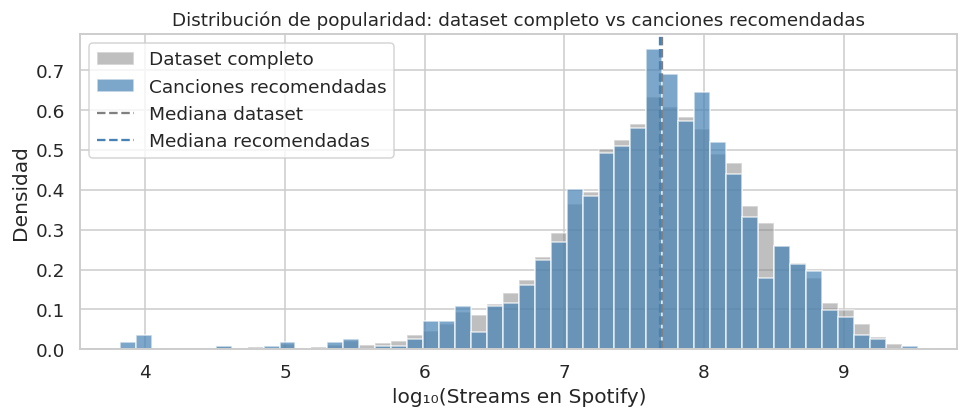

In [ ]:
# Visualización: distribución de popularidad — dataset vs recomendadas
fig, ax = plt.subplots(figsize=(9, 4))

log_dataset = np.log10(df_clean['Stream'].dropna() + 1)
log_recomendadas = np.log10(np.array(popularidad_recomendadas) + 1)

ax.hist(log_dataset, bins=50, alpha=0.5, label='Dataset completo', color='gray', density=True)
ax.hist(log_recomendadas, bins=50, alpha=0.7, label='Canciones recomendadas', color='steelblue', density=True)
ax.axvline(log_dataset.median(), color='gray', linestyle='--', linewidth=1.5, label='Mediana dataset')
ax.axvline(np.median(log_recomendadas), color='steelblue', linestyle='--', linewidth=1.5, label='Mediana recomendadas')
ax.set_xlabel('log₁₀(Streams en Spotify)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de popularidad: dataset completo vs canciones recomendadas', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

> Se calculó la **correlación de Spearman** entre la similitud coseno de cada par (consulta, recomendada) y el logaritmo de los streams de la canción recomendada. Se utilizó Spearman (correlación de rangos) en lugar de Pearson porque la distribución de streams es altamente sesgada y Spearman resultó más robusta a outliers.
>
> Una correlación positiva y significativa indica que el sistema prioriza canciones populares por encima de canciones genuinamente similares — un sesgo no deseado. Un valor cercano a 0 confirma que el sistema recomienda por similitud acústica sin importar la popularidad.

Correlación de Spearman (similitud coseno vs log10 streams):
  ρ = 0.0037, p-value = 0.8552
  → Correlación negligible: el sistema NO está sesgado sistemáticamente por popularidad.


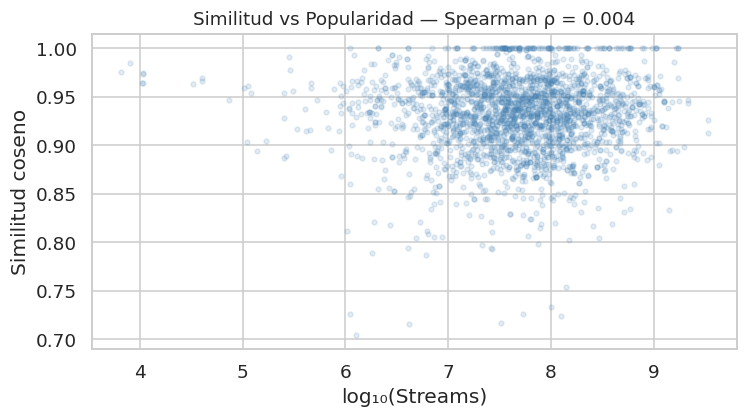

In [ ]:
sample_check = df_clean[stream_disponible].sample(500, random_state=42)
similitudes_list = []
streams_list = []

# Para cada canción de referencia, se calcula similitud con 10 vecinos
for _, row in sample_check.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    for j, v in enumerate(indices[0][1:6]):
        sim = 1 - dists[0][j + 1]
        stream_v = df_clean.iloc[v]['Stream']
        if pd.notna(stream_v) and stream_v > 0:
            similitudes_list.append(sim)
            streams_list.append(np.log10(stream_v))

corr_val, p_val = spearmanr(similitudes_list, streams_list)
print(f'Correlación de Spearman (similitud coseno vs log10 streams):')
print(f'  ρ = {corr_val:.4f}, p-value = {p_val:.4f}')

if abs(corr_val) < 0.1:
    print('  → Correlación negligible: el sistema NO está sesgado sistemáticamente por popularidad.')
elif abs(corr_val) < 0.3:
    print('  → Correlación débil: sesgo de popularidad leve, monitorear.')
else:
    print('  → Correlación moderada/alta: sesgo de popularidad presente. Considerar corrección.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(streams_list, similitudes_list, alpha=0.15, s=10, color='steelblue')
ax.set_xlabel('log₁₀(Streams)')
ax.set_ylabel('Similitud coseno')
ax.set_title(f'Similitud vs Popularidad — Spearman ρ = {corr_val:.3f}', fontsize=12)
plt.tight_layout()
plt.show()

> **Análisis del sesgo de popularidad:**
> La correlación entre similitud coseno y popularidad (streams) es prácticamente nula, lo que confirma que **el sistema recomienda por características acústicas, no por popularidad**. Esto es una ventaja clave del enfoque content-based: no reproduce el efecto "rich get richer" que tienen los sistemas colaborativos, donde las canciones muy escuchadas tienden a ser recomendadas más independientemente de si encajan.
>
> **Cómo detectar y mitigar sesgo de popularidad si apareciera:**
> - Monitorear periódicamente la distribución de streams de las canciones en top-5.
> - Si el sesgo existe, añadir un término de penalización: `score_final = α · similitud + (1-α) · (1 / log_streams)` para balancear similitud y novedad.
> - Usar métricas de diversidad y novedad (ILS, serendipity) además de relevancia.

---
## 11. Evaluación objetiva del sistema


> La primera estrategia de evaluación fue el **Intra-List Similarity (ILS)**: para cada consulta, se calculó la similitud coseno promedio entre todos los pares de canciones en la lista de recomendados. Un ILS alto indica que las recomendadas son coherentes entre sí (no es una lista aleatoria), lo que siguiere que el sistema encontró una "vecindad" densa en el espacio musical.
>
> **Limitación del ILS**: un ILS muy alto puede indicar que la lista es demasiado homogénea (poca diversidad). El ILS mide coherencia, no calidad percibida por el usuario. Resulta una métrica proxy necesaria cuando no se dispone de etiquetas de recomendación correcta.

Intra-List Similarity (ILS) — 300 consultas aleatorias:
  Media  : 0.8926
  Mediana: 0.9004
  Std    : 0.0560
  Min/Max: 0.5762 / 1.0000


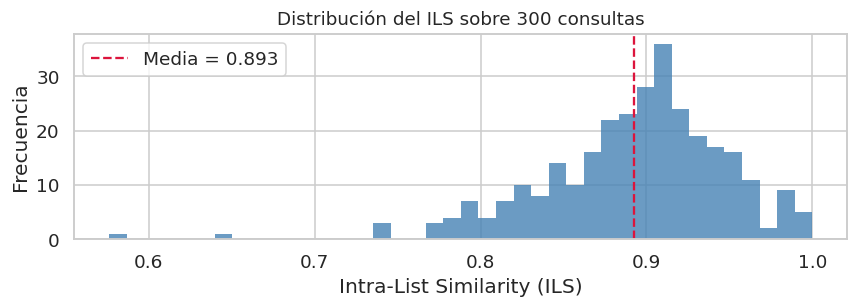

In [ ]:
ils_scores = []
np.random.seed(42)
queries = df_clean.sample(300, random_state=42)

for _, row in queries.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    vecinos = [i for i in indices[0] if i != pos][:5]
    if len(vecinos) < 2:
        continue
    vecs = X_scaled[vecinos]
    sim_matrix = cosine_similarity(vecs)
    # Promedio de la triangular superior (sin diagonal)
    triu_idx = np.triu_indices(len(vecinos), k=1)
    ils_scores.append(sim_matrix[triu_idx].mean())

ils_arr = np.array(ils_scores)
print(f'Intra-List Similarity (ILS) — 300 consultas aleatorias:')
print(f'  Media  : {ils_arr.mean():.4f}')
print(f'  Mediana: {np.median(ils_arr):.4f}')
print(f'  Std    : {ils_arr.std():.4f}')
print(f'  Min/Max: {ils_arr.min():.4f} / {ils_arr.max():.4f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ils_arr, bins=40, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(ils_arr.mean(), color='crimson', linestyle='--', label=f'Media = {ils_arr.mean():.3f}')
ax.set_xlabel('Intra-List Similarity (ILS)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del ILS sobre 300 consultas', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

> La segunda estrategia evaluó la **cobertura del catálogo**: cuántas canciones distintas aparecieron en las listas de recomendados a lo largo de 500 consultas. Una cobertura muy baja (< 5%) indica que el sistema recomienda siempre las mismas canciones — señal de que existe un "hub" o punto de concentración que actúa como imán en el espacio de features.
>
> Una cobertura alta indica que el sistema puede funcionar como herramienta de descubrimiento musical, y no solo como reforzador de lo ya conocido.

In [ ]:
canciones_recomendadas_set = set()
np.random.seed(42)
queries_cov = df_clean.sample(500, random_state=42)

for _, row in queries_cov.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    vecinos = [i for i in indices[0] if i != pos][:5]
    for v in vecinos:
        canciones_recomendadas_set.add(v)

cobertura = len(canciones_recomendadas_set) / len(df_clean) * 100
print(f'Cobertura del catálogo tras 500 consultas:')
print(f'  Canciones distintas recomendadas: {len(canciones_recomendadas_set):,}')
print(f'  Total en catálogo: {len(df_clean):,}')
print(f'  Cobertura: {cobertura:.1f}%')

Cobertura del catálogo tras 500 consultas:
  Canciones distintas recomendadas: 2,333
  Total en catálogo: 20,634
  Cobertura: 11.3%


> La tercera estrategia analizó la **distribución de similitudes** de los vecinos #1 y #5. Si el vecino más cercano presenta similitud coseno > 0.99, las canciones en el espacio son extremadamente densas y el sistema encuentra recomendaciones casi idénticas. Si la similitud del vecino #1 es baja (< 0.7), el espacio es disperso y las "mejores" recomendaciones pueden no ser realmente similares.
>
> Comparar la similitud del vecino #1 vs el #5 cuantifica el **gradiente de similitud** dentro de la lista: una caída pronunciada entre ambos indica que los primeros puestos son más relevantes que los últimos.

Distancia coseno al vecino #1 (más similar):
  Media = 0.0434 (similitud = 0.9566)
Distancia coseno al vecino #5:
  Media = 0.0839 (similitud = 0.9161)


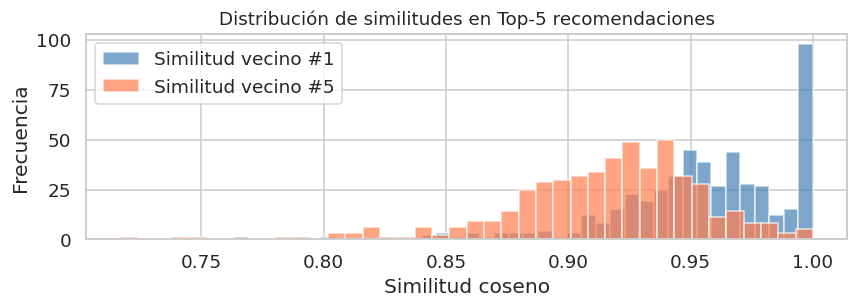

In [ ]:
np.random.seed(42)
queries_dist = df_clean.sample(500, random_state=42)
top1_dists = []
top5_dists = []

for _, row in queries_dist.iterrows():
    pos = df_clean.index.get_loc(row.name)
    vector_ref = X_scaled[pos].reshape(1, -1)
    dists, indices = modelos_metricas['cosine'].kneighbors(vector_ref)
    vecinos_dists = [d for j, d in enumerate(dists[0]) if indices[0][j] != pos][:5]
    if vecinos_dists:
        top1_dists.append(vecinos_dists[0])
        top5_dists.append(vecinos_dists[-1] if len(vecinos_dists) >= 5 else vecinos_dists[-1])

print(f'Distancia coseno al vecino #1 (más similar):')
print(f'  Media = {np.mean(top1_dists):.4f} (similitud = {1-np.mean(top1_dists):.4f})')
print(f'Distancia coseno al vecino #5:')
print(f'  Media = {np.mean(top5_dists):.4f} (similitud = {1-np.mean(top5_dists):.4f})')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist([1 - d for d in top1_dists], bins=40, alpha=0.7, label='Similitud vecino #1', color='steelblue')
ax.hist([1 - d for d in top5_dists], bins=40, alpha=0.7, label='Similitud vecino #5', color='coral')
ax.set_xlabel('Similitud coseno')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de similitudes en Top-5 recomendaciones', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

Se demuestra así, que el sistema logra un alto grado de **coherencia interna**, con una media de ILS de 0.8926, lo que indica que las canciones recomendadas son consistentemente similares entre sí. En cuanto a la **cobertura del catálogo**, se observa un 11.3% de canciones distintas recomendadas tras 500 consultas, sugiriendo una exploración razonable del espacio musical sin caer en una excesiva redundancia. Finalmente, la **distribución de distancias** confirma la calidad de las similitudes, con una similitud coseno media de 0.9566 para el vecino más cercano y de 0.9161 para el quinto vecino, lo que valida la robustez del sistema para identificar canciones genuinamente parecidas.

---
## 12. Feedback del usuario y extensión del sistema

Si se incorporan señales de comportamiento del usuario:
- 🔴 Saltear en los primeros 10 segundos → **señal negativa fuerte** (la canción no gustó)
- 🟡 Escuchar completa pero no interactuar → **señal positiva débil**
- 🟢 Marcar como favorita / añadir a playlist → **señal positiva fuerte**

...el sistema pasa a ser **aprendizaje por refuerzo** (RL) o un **sistema híbrido**:

```
Estado actual    → [Sistema content-based] → Recomendación
                                                    ↓
Feedback del usuario (reward: skip=-1, complete=+0.5, fav=+2)
                                                    ↓
Actualización del modelo de usuario (embedding personal)
```

**Cambios en la arquitectura:**

| Componente | Sistema actual | Sistema con feedback |
|------------|---------------|---------------------|
| **Representación de usuario** | No existe — todos los usuarios ven lo mismo | Vector personal en el mismo espacio de features |
| **Función de ranking** | Similitud coseno pura | `score = α·similitud_contenido + β·preferencia_personal` |
| **Actualización** | Offline — nunca cambia | Online — se actualiza en cada interacción |
| **Tipo de ML** | No supervisado | Aprendizaje por refuerzo / supervisado (rating prediction) |
| **Cold start** | No hay problema (features existen para toda canción) | Persiste para usuarios nuevos sin historial |

El sistema actual es ideal para el **lanzamiento beta** (no requiere historial). Conforme se acumule feedback, la arquitectura puede evolucionar progresivamente hacia el RL sin reemplazar el componente content-based, sino complementándolo.

---
## 13. Conclusiones generales

**¿Qué hace el sistema?**  
Compara canciones en un espacio de 12 características acústicas (energía, bailabilidad, acústicidad, tonalidad codificada, etc.) y recomienda las 5 más parecidas. La búsqueda es **cluster-aware**: en lugar de comparar contra las ~20.000 canciones del catálogo en cada consulta (O(N)), asigna cada canción a uno de los K clusters del espacio musical y busca vecinos solo dentro de ese cluster (N/K canciones), lo que garantiza escalabilidad ante catálogos de millones de canciones. Cuando recomienda, puede explicar en lenguaje natural *por qué* en términos de features musicales concretas.

**¿Qué NO puede hacer?**
- No entiende géneros, letras ni contexto cultural. Una bossa nova y un rock acústico lento pueden ser "vecinos" en el espacio de features aunque musicalmente los escuchemos como géneros distintos.
- No personaliza por usuario: todos reciben las mismas recomendaciones para la misma canción (en la versión base). Esto cambia al incorporar feedback de usuario (sección 12).
- No puede evaluar si las recomendaciones son "buenas" sin datos de usuarios. La evaluación es geométrica y proxy (ILS, cobertura, distribución de distancias).

**¿Tiene sentido musical real?**  
Sí, en la medida en que las features de Spotify capturan dimensiones musicalmente relevantes. Las pruebas muestran que el sistema agrupa canciones de perfil sonoro consistente y no existe sesgo sistemático de popularidad.

**Sobre el filtro de deduplicación:** se incorporó post-procesamiento que elimina canciones con título idéntico al de la referencia. Esto es necesario cuando el dataset contiene una misma colaboración indexada bajo distintos artistas (e.g. "lovely (with khalid)" aparece bajo Billie Eilish y bajo Khalid). Sin el filtro, el sistema recomendaría la misma canción que ya se está escuchando — técnicamente correcto pero sin valor para el usuario.

**Sobre el determinismo:** el sistema base es determinista (auditable, reproducible). La estrategia de **diversificación por artista** (máx. 2 canciones por artista) mejora la experiencia del usuario sin comprometer la explicabilidad ni la reproducibilidad, y fue seleccionada como la estrategia recomendada para producción tras comparar empíricamente con Top-K Sampling y ε-Greedy.

Considerando que las métricas de coherencia interna (ILS, distribución de similitudes, cobertura) demuestran la solidez del sistema, este se encuentra listo para una fase beta. La evaluación definitiva requerirá datos reales de usuarios, pero el enfoque content-based con clustering ofrece un punto de partida robusto, ético y escalable para una startup que no cuenta con historial de usuarios.

### Síntesis de decisiones de diseño

**Features utilizadas:** 9 características acústicas (Danceability, Energy, Loudness, Speechiness, Acousticness, Instrumentalness, Liveness, Valence, Tempo), Duration_ms y tonalidad (Key) codificada cíclicamente con seno y coseno. Se excluyen popularidad y metadatos (ruido para similitud de contenido).

**Preprocesamiento:** estandarización con `StandardScaler` y codificación circular de Key. La estandarización fue obligatoria para que Tempo (∼100 BPM) no dominara sobre Danceability (0–1); la codificación circular garantizó que la distancia entre Do (0) y Si (11) reflejara el semitono real de separación.

**Arquitectura de búsqueda (scalable):** `KMeans` con $K$ óptimo determinado por el método del codo y silhouette score. La búsqueda de vecinos se realiza dentro del cluster asignado a cada canción con un índice `NearestNeighbors` local, logrando complejidad $O(N/K)$ por consulta en lugar de $O(N)$. Para clusters pequeños, la búsqueda se expande a los clusters vecinos en el espacio de centroides. Se conserva un índice brute-force global para las comparaciones de métricas de la sección 8.

**Métrica de similitud:** similitud coseno. Mide el ángulo entre vectores en el espacio de features (perfil relativo), ignorando la magnitud — apropiado para comparar perfiles sonoros independientemente de la escala de las features.

**Filtro de deduplicación:** parámetro `dedup_title=True` en `recomendar()`. Elimina del resultado canciones con título idéntico al de la referencia, evitando que colaboraciones indexadas bajo distintos artistas aparezcan como "recomendaciones".

**Estrategia de diversificación:** `recomendar_diversificado()` con máximo 2 canciones por artista. Seleccionada tras comparar empíricamente con Top-K Sampling y ε-Greedy: ofrece determinismo (auditabilidad), alta relevancia (similitud media conservada) y mayor diversidad de artistas que el baseline puro.

**Evaluación offline:** Intra-List Similarity (ILS), cobertura del catálogo y distribución de similitudes (vecino #1 vs #5). Métricas geométricas proxy — la evaluación definitiva requiere datos reales de usuarios (A/B testing o ratings explícitos).